# 프로젝트 : 고등수학 단원분류 모델 만들기
## 목표

- 고등수학 문제 이미지를 입력받아 공통수학1/2의 6개 단원 중 하나로 분류하는 이미지 분류 모델을 만든다.
- 오답문제 사진을 입력하면 예측한 단원 top3를 정확도 순으로 보여준다.

분류 라벨:

- 공통수학1__다항식
- 공통수학1__방정식과부등식
- 공통수학1__도형의방정식
- 공통수학2__집합과명제
- 공통수학2__함수
- 공통수학2__경우의수

## 사용 데이터

- (AI HUB) 110.수학 과목 자동 풀이 데이터 / 111.수학 과목 문제생성 데이터
  - 이미지 zip
  - 라벨 JSON
  - JSON 안의 문제 파일명/단원 정보

- 전체 사용 가능 데이터는 9,773개이며, train/valid/test로 분리했다.

  - train: 7,798
  - valid: 996
  - test: 979

이미지 매칭 실패, 라벨 매핑 실패, 빈 문제 텍스트는 모두 0건으로 확인했다.  
train/valid/test 간 group overlap도 0으로 확인했다.

## 사용 모델 및 주요 설정

- 모델: `google/vit-base-patch16-384`
- 모델 유형: Vision Transformer 이미지 분류 모델
- 입력 이미지 크기: 384 x 384
- 라벨 수: 6
- processor: `AutoImageProcessor`
- model: `AutoModelForImageClassification`
- 기존 ImageNet 1000-class classifier head를 6-class 단원 분류 head로 교체하여 fine-tuning
- 학습 epoch: 3 기준

## 작업 히스토리 요약

1. 데이터 zip, 라벨 JSON, 이미지 매핑을 검증했다.
2. manifest를 생성하고 train/valid/test split을 만들었다.
3. ViT 모델이 빈 이미지, 실제 zip 이미지, Dataset/DataLoader batch를 정상 처리하는지 확인했다.
4. Trainer 1-step 학습 테스트로 전체 학습 루프가 정상 동작하는지 검증했다.
5. 기본 모델(v1)을 3 epoch 학습했다.
6. 실제 촬영 사진을 넣어보며 crop, padding, 실제 오답 사진 환경에서의 한계를 확인했다.
7. train 데이터에 이미지 증강을 추가한 v2, v2-light 실험을 진행했다.
8. OCR/text 보조 및 PaliGemma 활용 가능성을 다음 단계 후보로 검토했다.
9. OCR/text, VLM모델들의 시도는 Step 10. 모델선정과정에 정리된 내용을 볼 수 있다.

## Step 1. 환경설정

    - 작업 디렉토리 설정
    - 학습 데이터 zip파일 확인
    - Python 3.12.10 (PyTorch)

### 1-1. 기본 패키지 설치 확인

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# 0. 기본 패키지 설치 확인
# =========================

import sys
import subprocess
import importlib.util

# 데이터 가공과 이미지 확인에 필요한 기본 패키지
REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "PIL": "pillow",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
}

missing_packages = []

for import_name, pip_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(import_name) is None:
        missing_packages.append(pip_name)

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        *missing_packages
    ])
else:
    print("All basic packages are already installed.")

print("Dependency check OK.")

All basic packages are already installed.
Dependency check OK.


In [ ]:
# =========================
# 한글 폰트 자동 설정
# =========================

import platform
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def setup_korean_font():
    system = platform.system().lower()

    # 환경별 한글 폰트 후보
    font_candidates = []

    if system == "windows":
        font_candidates += [
            r"C:\Windows\Fonts\malgun.ttf",
            r"C:\Windows\Fonts\malgunbd.ttf",
            r"C:\Windows\Fonts\gulim.ttc",
        ]

    elif system == "darwin":  # macOS
        font_candidates += [
            "/System/Library/Fonts/AppleSDGothicNeo.ttc",
            "/Library/Fonts/AppleGothic.ttf",
        ]

    else:  # Linux, Colab, Kaggle
        font_candidates += [
            "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
            "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
            "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
            "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
        ]

    # 설치된 폰트 파일 중 첫 번째 사용
    for path in font_candidates:
        if Path(path).exists():
            font_name = fm.FontProperties(fname=path).get_name()
            plt.rcParams["font.family"] = font_name
            plt.rcParams["axes.unicode_minus"] = False
            print("한글 폰트 설정 완료:", font_name)
            print("font path:", path)
            return font_name

    # 파일 경로로 못 찾으면 matplotlib 등록 폰트 이름으로 시도
    fallback_names = [
        "Malgun Gothic",
        "AppleGothic",
        "NanumGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]

    installed_names = {f.name for f in fm.fontManager.ttflist}

    for name in fallback_names:
        if name in installed_names:
            plt.rcParams["font.family"] = name
            plt.rcParams["axes.unicode_minus"] = False
            print("한글 폰트 설정 완료:", name)
            return name

    print("한글 폰트를 찾지 못했습니다.")
    print("Windows는 보통 맑은 고딕이 있고, Colab/Kaggle은 Nanum/Noto 폰트 설치가 필요할 수 있습니다.")
    return None

korean_font = setup_korean_font()

한글 폰트를 찾지 못했습니다.
Windows는 보통 맑은 고딕이 있고, Colab/Kaggle은 Nanum/Noto 폰트 설치가 필요할 수 있습니다.


In [ ]:
# Colab/Kaggle Linux에서 한글 폰트가 없을 때만 실행
import subprocess
import sys
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Colab Linux에 한글 폰트 설치
subprocess.run(
    ["apt-get", "update", "-qq"],
    check=False
)
subprocess.run(
    ["apt-get", "install", "-y", "fonts-nanum"],
    check=False
)

# matplotlib 폰트 캐시 갱신
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("Korean font set: NanumGothic")

Korean font set: NanumGothic


### 1-2. 작업경로 설정 및 학습데이터 확인

In [ ]:
from pathlib import Path
import zipfile

# Drive에 올렸다면 먼저 마운트
from google.colab import drive
drive.mount("/content/drive")

# odap.zip 후보를 자동으로 찾기
search_roots = [
    Path("/content"),
    Path("/content/drive/MyDrive"),
]

zip_candidates = []

for root in search_roots:
    if root.exists():
        zip_candidates.extend(root.rglob("*odap*.zip"))

print("찾은 zip 후보:")
for p in zip_candidates:
    print("-", p)

assert zip_candidates, "odap 관련 zip 파일을 찾지 못했습니다. Colab 왼쪽 Files 또는 Google Drive 위치를 확인하세요."

# 가장 먼저 찾은 odap zip 사용
ODAP_ZIP = zip_candidates[0]
print("사용할 zip:", ODAP_ZIP)

# 압축 해제 위치
EXTRACT_DIR = Path("/content")

# 이미 풀었으면 다시 풀지 않기
marker = Path("/content/.odap_unzipped")

if not marker.exists():
    print("압축 해제 중...")
    with zipfile.ZipFile(ODAP_ZIP, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    marker.write_text(str(ODAP_ZIP))
    print("압축 해제 완료")
else:
    print("이미 압축 해제됨:", marker.read_text())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
찾은 zip 후보:
- /content/drive/MyDrive/odap.zip
- /content/drive/MyDrive/odap.zip
사용할 zip: /content/drive/MyDrive/odap.zip
압축 해제 중...
압축 해제 완료


In [ ]:
from pathlib import Path

# 압축이 풀린 /content 아래에서 110/111 폴더의 부모를 찾기
def find_data_root(base=Path("/content")):
    roots = []

    for p in base.rglob("110.*"):
        if p.is_dir():
            parent = p.parent
            if any(parent.glob("111.*")):
                roots.append(parent)

    roots = sorted(set(roots), key=lambda x: len(str(x)))
    assert roots, "110.*, 111.* 폴더를 포함한 DATA_ROOT를 찾지 못했습니다."

    return roots[0]

DATA_ROOT = find_data_root()
print("DATA_ROOT =", DATA_ROOT)

print("110 folders:")
for p in DATA_ROOT.glob("110.*"):
    print("-", p)

print("111 folders:")
for p in DATA_ROOT.glob("111.*"):
    print("-", p)

DATA_ROOT = /content
110 folders:
- /content/110.수학 과목 자동 풀이 데이터
111 folders:
- /content/111.수학 과목 문제생성 데이터


In [ ]:
from pathlib import Path

# term/split/원천·라벨링 조건에 맞는 zip 하나를 찾기
def pick_zip(term, split_name, kind_prefix, file_prefix):
    term_dirs = list(DATA_ROOT.glob(f"{term}.*"))
    assert term_dirs, f"{term} 폴더 없음: {DATA_ROOT}"

    term_dir = term_dirs[0]
    matches = []

    for p in term_dir.rglob(f"{file_prefix}*.zip"):
        # Training / Validation 폴더인지 확인
        has_split = split_name in p.parts

        # 01.원천데이터 / 02.라벨링데이터 폴더인지 확인
        has_kind = any(part.startswith(kind_prefix) for part in p.parts)

        if has_split and has_kind:
            matches.append(p)

    assert len(matches) == 1, (
        f"{term} {split_name} {kind_prefix} {file_prefix}: "
        f"{len(matches)}개 발견: {matches}"
    )

    return matches[0]

# 필요한 8개 zip 경로
ZIP_PATHS = {
    "110_train_label": pick_zip("110", "Training", "02.", "TL_1"),
    "110_train_image": pick_zip("110", "Training", "01.", "TS_1"),
    "110_valid_label": pick_zip("110", "Validation", "02.", "VL_1"),
    "110_valid_image": pick_zip("110", "Validation", "01.", "VS_1"),
    "111_train_label": pick_zip("111", "Training", "02.", "TL_1"),
    "111_train_image": pick_zip("111", "Training", "01.", "TS_1"),
    "111_valid_label": pick_zip("111", "Validation", "02.", "VL_1"),
    "111_valid_image": pick_zip("111", "Validation", "01.", "VS_1"),
}

# 찾은 zip 경로와 크기 출력
for name, path in ZIP_PATHS.items():
    size_mb = path.stat().st_size / 1024**2
    print(f"{name}: {path} ({size_mb:.1f} MB)")

110_train_label: /content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_1.문제_고등학교_공통수학.zip (1.9 MB)
110_train_image: /content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Training/01.원천데이터/TS_1.문제_고등학교_공통수학.zip (27.8 MB)
110_valid_label: /content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Validation/02.라벨링데이터/VL_1.문제_고등학교_공통수학.zip (0.2 MB)
110_valid_image: /content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Validation/01.원천데이터/VS_1.문제_고등학교_공통수학.zip (2.9 MB)
111_train_label: /content/111.수학 과목 문제생성 데이터/3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_1.문제_고등학교_공통수학.zip (3.7 MB)
111_train_image: /content/111.수학 과목 문제생성 데이터/3.개방데이터/1.데이터/Training/01.원천데이터/TS_1.문제_고등학교_공통수학.zip (62.0 MB)
111_valid_label: /content/111.수학 과목 문제생성 데이터/3.개방데이터/1.데이터/Validation/02.라벨링데이터/VL_1.문제_고등학교_공통수학.zip (0.4 MB)
111_valid_image: /content/111.수학 과목 문제생성 데이터/3.개방데이터/1.데이터/Validation/01.원천데이터/VS_1.문제_고등학교_공통수학.zip (6.9 MB)


In [ ]:
from pathlib import Path
import os
import sys
import platform
import zipfile

# =========================
# 0. Runtime detection
# =========================

def detect_runtime():
    if "google.colab" in sys.modules:
        return "colab"
    if Path("/kaggle/input").exists():
        return "kaggle"
    if platform.system().lower() == "windows":
        return "local_windows"
    return "local"

RUNTIME = detect_runtime()
print("Runtime:", RUNTIME)
print("Python:", sys.version)
print("OS:", platform.platform())

# =========================
# 1. Candidate data roots
# =========================
# 데이터 폴더 이름은 odap 이라고 가정.
# 코드 수정 없이 쓰려면 아래 후보 위치 중 하나에 C:\Projects\odap 구조를 그대로 두면 됨.
#
# Local Windows:
#   C:\Projects\odap
#
# Colab:
#   /content/odap
#   /content/drive/MyDrive/odap
#
# Kaggle:
#   /kaggle/input/odap
#   /kaggle/input/<your-dataset-name>/odap
#   /kaggle/working/odap

CANDIDATE_ROOTS = [
    Path(os.environ["ODAP_DATA_ROOT"]) if "ODAP_DATA_ROOT" in os.environ else None,
    Path(r"C:\Projects\odap"),
    Path.cwd() / "odap",
    Path("/content"),  # Colab에서 압축을 /content에 바로 푼 경우
    Path("/content/odap"),
    Path("/content/drive/MyDrive/odap"),
    Path("/kaggle/input/odap"),
    Path("/kaggle/working/odap"),
    Path("/kaggle/input"),
]

CANDIDATE_ROOTS = [p for p in CANDIDATE_ROOTS if p is not None]

def find_odap_root():
    for root in CANDIDATE_ROOTS:
        if not root.exists():
            continue

        # root 자체가 odap 폴더인 경우
        if (root / "110.수학 과목 자동 풀이 데이터").exists() and (root / "111.수학 과목 문제생성 데이터").exists():
            return root

        # Kaggle처럼 /kaggle/input 아래 한 단계 더 들어가 있는 경우
        for child in root.glob("*"):
            if child.is_dir():
                if (child / "110.수학 과목 자동 풀이 데이터").exists() and (child / "111.수학 과목 문제생성 데이터").exists():
                    return child

    return None

DATA_ROOT = find_odap_root()

if DATA_ROOT is None:
    print("ODAP data root not found.")
    print("Place the dataset in one of these locations:")
    for p in CANDIDATE_ROOTS:
        print(" -", p)
    raise FileNotFoundError("Could not find odap dataset root.")

print("DATA_ROOT:", DATA_ROOT)

# =========================
# 2. Dataset paths
# =========================

DATA_110 = DATA_ROOT / "110.수학 과목 자동 풀이 데이터"
DATA_111 = DATA_ROOT / "111.수학 과목 문제생성 데이터"

PATHS = {
    "110_label_train": DATA_110 / r"3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_1.문제_고등학교_공통수학.zip",
    "110_image_train": DATA_110 / r"3.개방데이터/1.데이터/Training/01.원천데이터/TS_1.문제_고등학교_공통수학.zip",
    "110_label_valid": DATA_110 / r"3.개방데이터/1.데이터/Validation/02.라벨링데이터/VL_1.문제_고등학교_공통수학.zip",
    "110_image_valid": DATA_110 / r"3.개방데이터/1.데이터/Validation/01.원천데이터/VS_1.문제_고등학교_공통수학.zip",

    "111_label_train": DATA_111 / r"3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_1.문제_고등학교_공통수학.zip",
    "111_image_train": DATA_111 / r"3.개방데이터/1.데이터/Training/01.원천데이터/TS_1.문제_고등학교_공통수학.zip",
    "111_label_valid": DATA_111 / r"3.개방데이터/1.데이터/Validation/02.라벨링데이터/VL_1.문제_고등학교_공통수학.zip",
    "111_image_valid": DATA_111 / r"3.개방데이터/1.데이터/Validation/01.원천데이터/VS_1.문제_고등학교_공통수학.zip",
}

# =========================
# 3. Validate paths
# =========================

missing = []
for name, path in PATHS.items():
    ok = path.exists()
    print(f"{name:16s}", ok, path)
    if not ok:
        missing.append((name, path))

if missing:
    raise FileNotFoundError(f"Missing {len(missing)} required zip files.")

# =========================
# 4. Quick zip sanity check
# =========================

def count_zip_files(zip_path, suffix):
    with zipfile.ZipFile(zip_path) as zf:
        return sum(1 for name in zf.namelist() if name.lower().endswith(suffix))

for name, path in PATHS.items():
    if "label" in name:
        count = count_zip_files(path, ".json")
    else:
        count = count_zip_files(path, ".png")
    print(f"{name:16s} files={count}")

print("First cell OK.")

Runtime: colab
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
OS: Linux-6.6.122+-x86_64-with-glibc2.35
DATA_ROOT: /content
110_label_train  True /content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_1.문제_고등학교_공통수학.zip
110_image_train  True /content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Training/01.원천데이터/TS_1.문제_고등학교_공통수학.zip
110_label_valid  True /content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Validation/02.라벨링데이터/VL_1.문제_고등학교_공통수학.zip
110_image_valid  True /content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Validation/01.원천데이터/VS_1.문제_고등학교_공통수학.zip
111_label_train  True /content/111.수학 과목 문제생성 데이터/3.개방데이터/1.데이터/Training/02.라벨링데이터/TL_1.문제_고등학교_공통수학.zip
111_image_train  True /content/111.수학 과목 문제생성 데이터/3.개방데이터/1.데이터/Training/01.원천데이터/TS_1.문제_고등학교_공통수학.zip
111_label_valid  True /content/111.수학 과목 문제생성 데이터/3.개방데이터/1.데이터/Validation/02.라벨링데이터/VL_1.문제_고등학교_공통수학.zip
111_image_valid  True /content/111.수학 과목 문제생성 데이터/3.개방데이터/1.데이터/Validation/01.원천데이터/VS_1.문제_고등학교_공통수학.zip
110_label_train  

## Step 2. 데이터 생성/검증 1차 흐름

- 아래 셀들은 초기에 만든 manifest/split 검증 흐름이다.  
뒤쪽 Step 5에서 최신 manifest/split을 다시 생성하므로, 최종 학습에는 Step 5 결과를 사용한다.

### 2-1. 라벨 매핑 함수 / 매핑 테스트

- AI Hub의 term/unit을 우리가 쓸 6개 단원 라벨로 바꾸는 규칙 정의

In [ ]:
# =========================
# 2-1. 단원 라벨 매핑
# =========================

# 최종적으로 모델이 분류할 6개 라벨
LABELS = [
    "공통수학1__다항식",
    "공통수학1__방정식과부등식",
    "공통수학1__도형의방정식",
    "공통수학2__집합과명제",
    "공통수학2__함수",
    "공통수학2__경우의수",
]

# Hugging Face 모델 학습에 사용할 라벨 번호 매핑
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

# AI Hub의 term/unit 코드를 우리가 쓸 단원 라벨로 변환
def map_unit(term, unit):
    term = int(term)
    unit = str(unit).zfill(2)

    # 공통수학1: 다항식
    if term == 1 and unit in ["01", "02"]:
        return "공통수학1", "다항식", "공통수학1__다항식"

    # 공통수학1: 방정식과 부등식
    if term == 1 and unit in ["03", "04", "05", "06"]:
        return "공통수학1", "방정식과부등식", "공통수학1__방정식과부등식"

    # 공통수학1: 도형의 방정식
    if term == 1 and unit in ["07", "08", "09"]:
        return "공통수학1", "도형의방정식", "공통수학1__도형의방정식"

    # 공통수학2: 집합과 명제
    if term == 2 and unit in ["01", "02", "03"]:
        return "공통수학2", "집합과명제", "공통수학2__집합과명제"

    # 공통수학2: 함수
    if term == 2 and unit in ["04", "05", "06"]:
        return "공통수학2", "함수", "공통수학2__함수"

    # 공통수학2: 경우의 수
    if term == 2 and unit == "07":
        return "공통수학2", "경우의수", "공통수학2__경우의수"

    # 매핑되지 않는 데이터는 이후 제외하거나 검수 대상으로 분리
    return None, None, None


# 매핑 규칙이 의도대로 동작하는지 간단히 확인
checks = [
    (1, "01", "공통수학1__다항식"),
    (1, "02", "공통수학1__다항식"),
    (1, "03", "공통수학1__방정식과부등식"),
    (1, "06", "공통수학1__방정식과부등식"),
    (1, "07", "공통수학1__도형의방정식"),
    (1, "09", "공통수학1__도형의방정식"),
    (2, "01", "공통수학2__집합과명제"),
    (2, "03", "공통수학2__집합과명제"),
    (2, "04", "공통수학2__함수"),
    (2, "06", "공통수학2__함수"),
    (2, "07", "공통수학2__경우의수"),
]

for term, unit, expected_label in checks:
    subject, mapped_unit, label = map_unit(term, unit)
    assert label == expected_label, (term, unit, label, expected_label)

assert len(label2id) == 6
assert len(id2label) == 6

print("Label mapping OK.")
print(label2id)

Label mapping OK.
{'공통수학1__다항식': 0, '공통수학1__방정식과부등식': 1, '공통수학1__도형의방정식': 2, '공통수학2__집합과명제': 3, '공통수학2__함수': 4, '공통수학2__경우의수': 5}


### 2-2. 라벨 JSON을 읽어서 manifest DataFrame 만들기

In [ ]:
# =========================
# 2-2. 라벨 JSON을 읽어 manifest 만들기
# =========================

import json
import zipfile
import pandas as pd
from pathlib import Path

# zip 내부 경로를 파일명 기준으로 빠르게 찾기 위한 인덱스 생성
def build_zip_name_index(zip_path, suffix):
    index = {}
    with zipfile.ZipFile(zip_path) as zf:
        for name in zf.namelist():
            if name.lower().endswith(suffix):
                index[Path(name).name] = name
    return index

# 한 데이터셋 split의 라벨 zip과 이미지 zip을 읽어 manifest row 생성
def read_problem_manifest(source_dataset, split, label_zip_path, image_zip_path):
    image_index = build_zip_name_index(image_zip_path, ".png")
    rows = []

    with zipfile.ZipFile(label_zip_path) as zf:
        json_names = [name for name in zf.namelist() if name.lower().endswith(".json")]

        for json_name in json_names:
            with zf.open(json_name) as f:
                obj = json.loads(f.read().decode("utf-8-sig"))

            question_filename = obj.get("question_filename")
            question_info = obj.get("question_info", [{}])[0]
            ocr_info = obj.get("OCR_info", [{}])[0]

            question_text = ocr_info.get("question_text")
            question_term = question_info.get("question_term")
            question_unit = question_info.get("question_unit")
            question_topic = question_info.get("question_topic")
            question_topic_name = question_info.get("question_topic_name")
            question_difficulty = question_info.get("question_difficulty")

            mapped_subject, mapped_unit, label = map_unit(question_term, question_unit)

            image_path_in_zip = image_index.get(question_filename)
            image_exists = image_path_in_zip is not None

            rows.append({
                "source_dataset": source_dataset,
                "split_original": split,
                "label_zip": str(label_zip_path),
                "label_path_in_zip": json_name,
                "image_zip": str(image_zip_path),
                "image_path_in_zip": image_path_in_zip,
                "image_exists": image_exists,
                "question_filename": question_filename,
                "question_text": question_text,
                "question_term": question_term,
                "question_unit": str(question_unit).zfill(2) if question_unit is not None else None,
                "question_topic": question_topic,
                "question_topic_name": question_topic_name,
                "question_difficulty": question_difficulty,
                "mapped_subject": mapped_subject,
                "mapped_unit": mapped_unit,
                "label": label,
                "label_id": label2id.get(label),
            })

    return pd.DataFrame(rows)


# 110/111 train/valid 전체를 하나의 manifest로 합치기
manifest_parts = [
    read_problem_manifest("110", "train", PATHS["110_label_train"], PATHS["110_image_train"]),
    read_problem_manifest("110", "valid", PATHS["110_label_valid"], PATHS["110_image_valid"]),
    read_problem_manifest("111", "train", PATHS["111_label_train"], PATHS["111_image_train"]),
    read_problem_manifest("111", "valid", PATHS["111_label_valid"], PATHS["111_image_valid"]),
]

manifest = pd.concat(manifest_parts, ignore_index=True)

print("manifest rows:", len(manifest))
display(manifest.head())

manifest rows: 9773


,source_dataset,split_original,label_zip,label_path_in_zip,image_zip,image_path_in_zip,image_exists,question_filename,question_text,question_term,question_unit,question_topic,question_topic_name,question_difficulty,mapped_subject,mapped_unit,label,label_id
0,110,train,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25766_84187.json,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25766_84187.png,True,H_1_01_25766_84187.png,"두 다항식 $A=3x^3-3x^2+5x$, $B=x^2-3x+6$에 대하여 $A-3...",1,01,0101001,다항식의 덧셈과 뺄셈,2,공통수학1,다항식,공통수학1__다항식,0
1,110,train,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25790_84306.json,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25790_84306.png,True,H_1_01_25790_84306.png,"두 다항식 $A$, $B$에 대하여 $A+B=8x^2-6xy+y^2$, $2A-B=...",1,01,0101001,다항식의 덧셈과 뺄셈,2,공통수학1,다항식,공통수학1__다항식,0
2,110,train,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25768_84195.json,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25768_84195.png,True,H_1_01_25768_84195.png,"두 다항식 $A=4x^2-2xy+y^2$, $B=-x^2-3xy+4y^2$에 대하여...",1,01,0101001,다항식의 덧셈과 뺄셈,2,공통수학1,다항식,공통수학1__다항식,0
3,110,train,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25802_84340.json,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25802_84340.png,True,H_1_01_25802_84340.png,다항식 $(x^2+2xy-y^2)(-x+3y)$를 전개하시오.,1,01,0101002,다항식의 전개,1,공통수학1,다항식,공통수학1__다항식,0
4,110,train,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25766_84188.json,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25766_84188.png,True,H_1_01_25766_84188.png,"세 다항식 $A=2x^3-4x^2+5$, $B=x^2+x-6$, $C=4x^2+5x...",1,01,0101001,다항식의 덧셈과 뺄셈,2,공통수학1,다항식,공통수학1__다항식,0


### 2-3. manifest 품질 검사와 라벨 분포 확인

In [ ]:
# =========================
# 2-3. manifest 품질 검사와 라벨 분포 확인
# =========================

# 기본 결측/매핑/이미지 매칭 상태 확인
print("전체 rows:", len(manifest))
print("이미지 매칭 실패:", (~manifest["image_exists"]).sum())
print("라벨 매핑 실패:", manifest["label"].isna().sum())
print("question_text 결측:", manifest["question_text"].isna().sum())
print("question_text 빈 문자열:", (manifest["question_text"].fillna("").str.strip() == "").sum())

# 학습에 바로 쓸 수 있는 row만 추림
usable_manifest = manifest[
    (manifest["image_exists"] == True) &
    (manifest["label"].notna()) &
    (manifest["question_text"].notna()) &
    (manifest["question_text"].str.strip() != "")
].copy()

print("사용 가능 rows:", len(usable_manifest))

# 라벨별 데이터 개수
print("\n라벨별 개수")
display(
    usable_manifest["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

# 원본 데이터셋별 개수
print("\nsource_dataset / split_original별 개수")
display(
    usable_manifest
    .groupby(["source_dataset", "split_original"])
    .size()
    .reset_index(name="count")
)

# 라벨별 원본 split 분포
print("\n라벨별 split 분포")
display(
    usable_manifest
    .groupby(["label", "split_original"])
    .size()
    .reset_index(name="count")
    .sort_values(["label", "split_original"])
)

# 라벨별 주요 topic_name 확인
print("\n라벨별 주요 topic_name")
for label in LABELS:
    print("\n==", label)
    display(
        usable_manifest[usable_manifest["label"] == label]["question_topic_name"]
        .value_counts()
        .head(10)
        .rename_axis("question_topic_name")
        .reset_index(name="count")
    )

전체 rows: 9773
이미지 매칭 실패: 0
라벨 매핑 실패: 0
question_text 결측: 0
question_text 빈 문자열: 0
사용 가능 rows: 9773

라벨별 개수


,label,count
0,공통수학1__방정식과부등식,2233
1,공통수학2__집합과명제,1794
2,공통수학2__함수,1695
3,공통수학1__도형의방정식,1667
4,공통수학1__다항식,1400
5,공통수학2__경우의수,984



source_dataset / split_original별 개수


,source_dataset,split_original,count
0,110,train,3001
1,110,valid,314
2,111,train,5811
3,111,valid,647



라벨별 split 분포


...

,question_topic_name,count
0,유한집합의 원소의 개수,141
1,"충분조건, 필요조건, 필요충분조건이 되는 상수 구하기",106
2,부분집합 구하기,91
3,산술평균과 기하평균의 관계,86
4,유한집합의 원소의 개수의 활용,68
5,진리집합,67
6,여집합과 차집합,65
7,서로 같은 집합,65
8,집합의 표현,57
9,"명제의 역, 대우의 참, 거짓",50



== 공통수학2__함수


,question_topic_name,count
0,무리함수의 그래프의 성질,120
1,역함수의 정의,87
2,무리식의 값 구하기,83
3,합성함수의 함숫값,80
4,유리함수의 그래프의 성질,72
5,무리함수의 합성함수와 역함수,71
6,유리식의 값 구하기,71
7,f○g에 대한 조건이 주어진 경우,54
8,절댓값 기호를 포함한 식의 그래프,54
9,"유리식의 덧셈, 뺄셈, 곱셈, 나눗셈",53



== 공통수학2__경우의수


,question_topic_name,count
0,조합의 수,92
1,"합의 법칙, 곱의 법칙",76
2,"수형도, 도로망, 색칠",74
3,순열의 계산,74
4,"분할, 분배하는 경우의 수",74
5,자리에 대한 조건이 있는 순열의 수,62
6,조합의 계산,60
7,이웃하거나 이웃하지 않는 순열의 수,58
8,특정한 것을 포함하거나 포함하지 않는 조합의 수,48
9,다각형의 개수,47


### 2-4. 중복 검사와 학습용 기본 데이터 확정

    - 같은 문제나 같은 이미지가 train/test에 동시에 들어가지 않도록

In [ ]:
# =========================
# 2-4. 중복 검사와 학습용 기본 데이터 확정
# =========================

# 학습에 쓸 기본 manifest
dataset_df = usable_manifest.copy().reset_index(drop=True)

# 각 row를 구분할 고유 ID
dataset_df["sample_id"] = (
    dataset_df["source_dataset"].astype(str)
    + "_"
    + dataset_df["split_original"].astype(str)
    + "_"
    + dataset_df["question_filename"].astype(str)
)

# 텍스트 정규화: 중복 확인용
dataset_df["question_text_norm"] = (
    dataset_df["question_text"]
    .fillna("")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("전체 샘플 수:", len(dataset_df))
print("sample_id 중복:", dataset_df["sample_id"].duplicated().sum())
print("question_filename 중복:", dataset_df["question_filename"].duplicated().sum())
print("question_text exact 중복:", dataset_df["question_text_norm"].duplicated().sum())

# 중복 텍스트가 있다면 일부 확인
dup_texts = dataset_df[dataset_df["question_text_norm"].duplicated(keep=False)].copy()

print("중복 텍스트 포함 rows:", len(dup_texts))

if len(dup_texts) > 0:
    display(
        dup_texts[
            [
                "source_dataset",
                "split_original",
                "question_filename",
                "label",
                "question_topic_name",
                "question_text_norm",
            ]
        ]
        .sort_values("question_text_norm")
        .head(20)
    )

# 같은 텍스트인데 라벨이 다르게 붙은 위험 케이스 확인
label_conflict = (
    dataset_df
    .groupby("question_text_norm")["label"]
    .nunique()
    .reset_index(name="label_count")
)

conflict_texts = label_conflict[label_conflict["label_count"] > 1]

print("같은 텍스트인데 라벨이 다른 케이스:", len(conflict_texts))

if len(conflict_texts) > 0:
    conflict_examples = dataset_df[
        dataset_df["question_text_norm"].isin(conflict_texts["question_text_norm"])
    ][
        [
            "source_dataset",
            "split_original",
            "question_filename",
            "label",
            "question_topic_name",
            "question_text_norm",
        ]
    ].sort_values("question_text_norm")

    display(conflict_examples.head(30))

전체 샘플 수: 9773
sample_id 중복: 0
question_filename 중복: 0
question_text exact 중복: 101
중복 텍스트 포함 rows: 150


,source_dataset,split_original,question_filename,label,question_topic_name,question_text_norm
7876,111,train,H_2_04_30655_112406.png,공통수학2__함수,함수의 그래프와 합성함수,$1\le x\le5$에서 정의된 함수 $y=f(x)$의 그래프가 다음 그림과 같을...
7790,111,train,H_2_04_30655_112403.png,공통수학2__함수,함수의 그래프와 합성함수,$1\le x\le5$에서 정의된 함수 $y=f(x)$의 그래프가 다음 그림과 같을...
7882,111,train,H_2_04_30655_112404.png,공통수학2__함수,함수의 그래프와 합성함수,$1\le x\le5$에서 정의된 함수 $y=f(x)$의 그래프가 다음 그림과 같을...
7871,111,train,H_2_04_30655_112405.png,공통수학2__함수,함수의 그래프와 합성함수,$1\le x\le5$에서 정의된 함수 $y=f(x)$의 그래프가 다음 그림과 같을...
2418,110,train,H_2_05_31008_114135.png,공통수학2__함수,유리식의 값 구하기,"넓이가 각각 $A$, $B$, $C$, $D$인 정사각형을 다음 그림과 같이 빈틈없..."
2433,110,train,H_2_05_31008_114131.png,공통수학2__함수,유리식의 값 구하기,"넓이가 각각 $A$, $B$, $C$, $D$인 정사각형을 다음 그림과 같이 빈틈없..."
3232,110,valid,H_2_05_31008_114133.png,공통수학2__함수,유리식의 값 구하기,"넓이가 각각 $A$, $B$, $C$, $D$인 정사각형을 다음 그림과 같이 빈틈없..."
8156,111,train,H_2_05_31008_114132.png,공통수학2__함수,유리식의 값 구하기,"넓이가 각각 A, B, C, D인 정사각형을 다음 그림과 같이 빈틈없이 붙여 놓았을..."
8166,111,train,H_2_05_31008_114136.png,공통수학2__함수,유리식의 값 구하기,"넓이가 각각 A, B, C, D인 정사각형을 다음 그림과 같이 빈틈없이 붙여 놓았을..."
8197,111,train,H_2_05_31008_114134.png,공통수학2__함수,유리식의 값 구하기,"넓이가 각각 A, B, C, D인 정사각형을 다음 그림과 같이 빈틈없이 붙여 놓았을..."


같은 텍스트인데 라벨이 다른 케이스: 0


- 같은 텍스트인데 라벨이 다른 케이스: 0 이므로,  라벨 충돌은 없고, 같은 문제 문장/유사 변형이 여러 이미지로 존재하는 상태.
- 이미지 모델에서는 이런 중복이 train/test에 나뉘면 평가가 살짝 좋게 나올 수 있으니, split할 때 같은 question_text_norm은 같은 split에 넣도록 한다.

### 2-5. 학습데이터 train/valid/test 나누기

In [ ]:
# =========================
# 2-5. 중복 텍스트가 갈라지지 않도록 train/valid/test 나누기
# =========================

from sklearn.model_selection import train_test_split

# 같은 question_text_norm은 같은 split에 들어가도록 그룹 단위로 split
group_df = (
    dataset_df
    .groupby("question_text_norm", as_index=False)
    .agg(
        label=("label", "first"),
        group_size=("sample_id", "count"),
    )
)

# 같은 텍스트에 여러 라벨이 붙은 경우는 앞 셀에서 0개임을 확인했지만, 한 번 더 안전하게 확인
conflict_check = (
    dataset_df
    .groupby("question_text_norm")["label"]
    .nunique()
    .max()
)
assert conflict_check == 1, f"같은 텍스트에 여러 라벨이 섞여 있습니다: max label count={conflict_check}"

print("전체 row 수:", len(dataset_df))
print("고유 텍스트 그룹 수:", len(group_df))
print("중복으로 묶인 row 수:", int((group_df["group_size"] - 1).clip(lower=0).sum()))

# 1차: train 80%, temp 20%
train_groups, temp_groups = train_test_split(
    group_df,
    test_size=0.20,
    random_state=42,
    stratify=group_df["label"],
)

# 2차: temp를 valid 10%, test 10%로 분리
valid_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    random_state=42,
    stratify=temp_groups["label"],
)

# 그룹별 split 매핑
group_to_split = {}

for text in train_groups["question_text_norm"]:
    group_to_split[text] = "train"

for text in valid_groups["question_text_norm"]:
    group_to_split[text] = "valid"

for text in test_groups["question_text_norm"]:
    group_to_split[text] = "test"

dataset_df["split"] = dataset_df["question_text_norm"].map(group_to_split)

assert dataset_df["split"].isna().sum() == 0

# 최종 split 분포 확인
print("\n최종 split별 row 수")
display(
    dataset_df["split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="count")
)

print("\n최종 split/label 분포")
display(
    dataset_df
    .groupby(["split", "label"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "label"])
)

# 같은 텍스트가 여러 split에 갈라졌는지 확인
split_leak_check = (
    dataset_df
    .groupby("question_text_norm")["split"]
    .nunique()
    .max()
)

assert split_leak_check == 1, f"같은 텍스트가 여러 split에 나뉘었습니다: {split_leak_check}"

print("\nSplit OK.")

전체 row 수: 9773
고유 텍스트 그룹 수: 9672
중복으로 묶인 row 수: 101

최종 split별 row 수


,split,count
0,train,7821
1,valid,982
2,test,970



최종 split/label 분포


,split,label,count
0,test,공통수학1__다항식,140
1,test,공통수학1__도형의방정식,166
2,test,공통수학1__방정식과부등식,223
3,test,공통수학2__경우의수,95
4,test,공통수학2__집합과명제,179
5,test,공통수학2__함수,167
6,train,공통수학1__다항식,1120
7,train,공통수학1__도형의방정식,1336
8,train,공통수학1__방정식과부등식,1787
9,train,공통수학2__경우의수,789



Split OK.


## Step 3. 이미지 전처리

### 3-1. zip 안의 문제 이미지 확인

            label  question_topic_name        question_filename
0      공통수학1__다항식                곱셈 공식   H_1_01_25840_84021.png
1  공통수학1__방정식과부등식         허수단위 i의 거듭제곱   H_1_03_26446_88121.png
2   공통수학1__도형의방정식         점과 직선 사이의 거리   H_1_07_27705_93299.png
3    공통수학2__집합과명제            명제의 참, 거짓  H_2_03_29965_109706.png
4       공통수학2__함수              역함수의 정의  H_2_04_30775_111668.png
5     공통수학2__경우의수  자리에 대한 조건이 있는 순열의 수  H_2_07_28571_101056.png


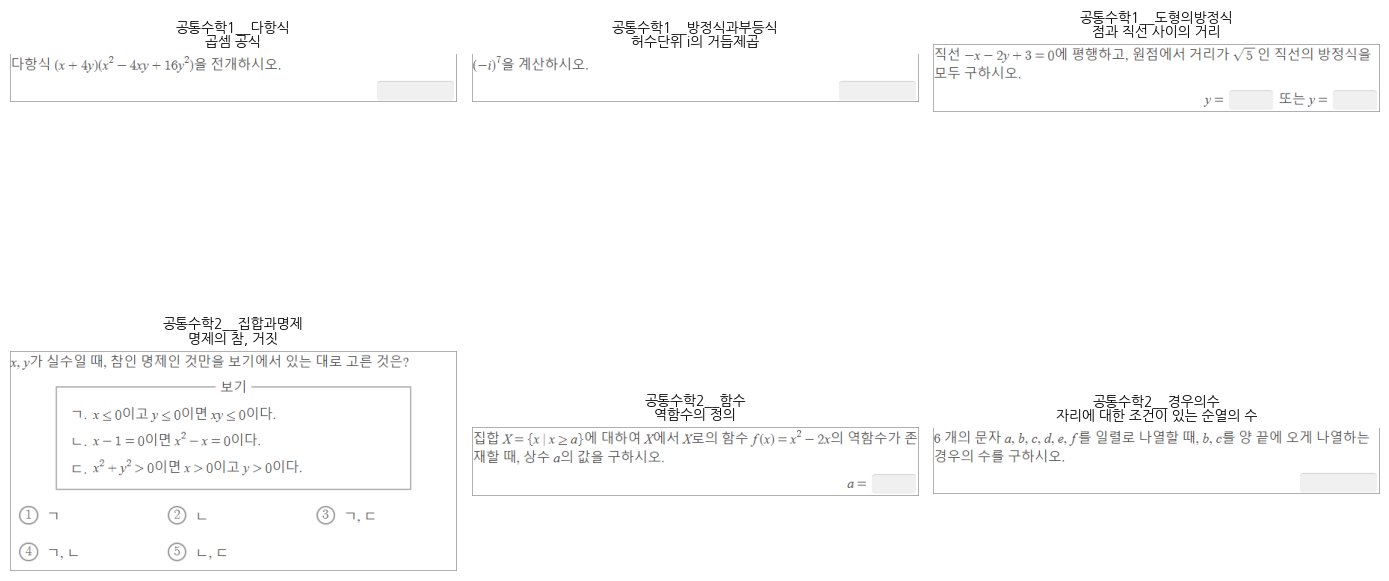

샘플 이미지 크기 통계


,width,height
count,200.0,200.000000
mean,598.0,140.205000
std,0.0,99.811747
min,598.0,64.000000
25%,598.0,89.000000
50%,598.0,92.000000
75%,598.0,159.000000
max,598.0,599.000000


In [ ]:
# =========================
# 3-1. zip 안의 문제 이미지 열어보기
# =========================

from PIL import Image
import matplotlib.pyplot as plt
import zipfile
from io import BytesIO
import pandas as pd

# zip 안의 이미지를 PIL Image로 읽는 함수
def load_image_from_zip(image_zip_path, image_path_in_zip):
    with zipfile.ZipFile(image_zip_path) as zf:
        with zf.open(image_path_in_zip) as f:
            image = Image.open(BytesIO(f.read())).convert("RGB")
    return image

# 라벨별 샘플 1개씩 안전하게 선택
sample_rows = []

for label in LABELS:
    one_row = dataset_df[dataset_df["label"] == label].sample(1, random_state=42)
    sample_rows.append(one_row)

sample_rows = pd.concat(sample_rows, ignore_index=True)

print(sample_rows[["label", "question_topic_name", "question_filename"]])

# 라벨별 이미지 표시
plt.figure(figsize=(14, 10))

for i, row in sample_rows.iterrows():
    image = load_image_from_zip(row["image_zip"], row["image_path_in_zip"])

    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(
        f"{row['label']}\n{row['question_topic_name']}",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# 이미지 크기 분포 간단 확인
sizes = []

for _, row in dataset_df.sample(200, random_state=42).iterrows():
    image = load_image_from_zip(row["image_zip"], row["image_path_in_zip"])
    sizes.append(image.size)

size_df = pd.DataFrame(sizes, columns=["width", "height"])

print("샘플 이미지 크기 통계")
display(size_df.describe())

### 3-2. 이미지 전처리

    - 전체 문제 이미지를 같은 크기로 생성
    - 원본 이미지
        - 비율 유지
        - 224x224 흰 배경에 padding
        - 글자가 찌그러지지 않는지 확인

label: 공통수학1__방정식과부등식
topic: 이차함수의 최대, 최소
original size: (598, 278)
processed size: (224, 224)


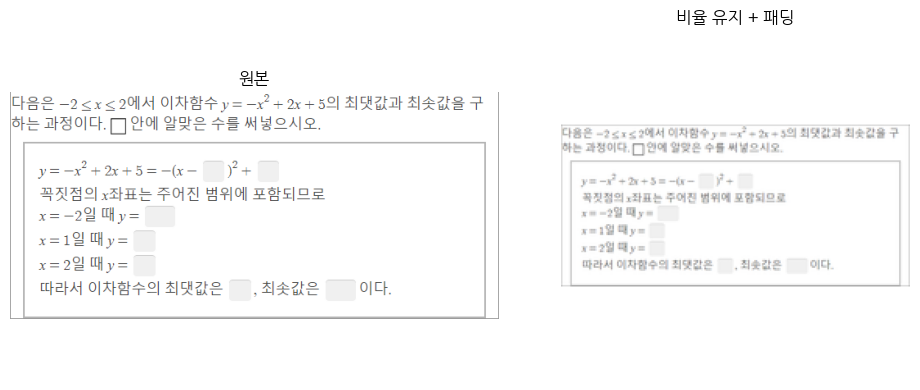

In [ ]:
# =========================
# 3-2. 이미지 비율 유지 resize + padding 테스트
# =========================

from PIL import ImageOps

# 원본 비율을 유지하면서 정사각형 캔버스에 맞추기
def resize_with_padding(image, size=224, fill_color=(255, 255, 255)):
    image = image.convert("RGB")

    # 긴 변이 size가 되도록 비율 유지 resize
    image.thumbnail((size, size), Image.Resampling.LANCZOS)

    # 흰색 정사각형 배경 생성
    canvas = Image.new("RGB", (size, size), fill_color)

    # 가운데 배치
    x = (size - image.width) // 2
    y = (size - image.height) // 2
    canvas.paste(image, (x, y))

    return canvas

# 샘플 이미지 하나로 전처리 전/후 확인
row = dataset_df.sample(1, random_state=7).iloc[0]
original_image = load_image_from_zip(row["image_zip"], row["image_path_in_zip"])
processed_image = resize_with_padding(original_image, size=224)

print("label:", row["label"])
print("topic:", row["question_topic_name"])
print("original size:", original_image.size)
print("processed size:", processed_image.size)

plt.figure(figsize=(10, 4))

ax = plt.subplot(1, 2, 1)
ax.imshow(original_image)
ax.axis("off")
ax.set_title("원본")

ax = plt.subplot(1, 2, 2)
ax.imshow(processed_image)
ax.axis("off")
ax.set_title("비율 유지 + 패딩")

plt.tight_layout()
plt.show()

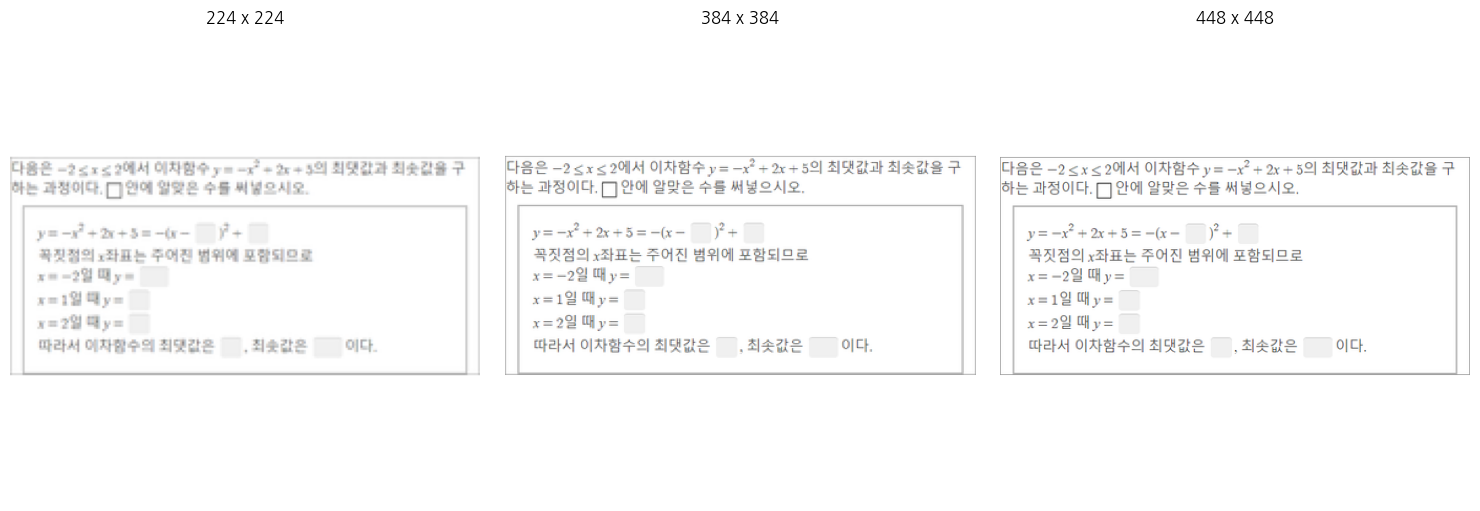

In [ ]:
# =========================
# 3-2-1. 입력 크기별 전처리 품질 비교
# =========================

sizes_to_check = [224, 384, 448]

plt.figure(figsize=(15, 5))

for i, size in enumerate(sizes_to_check):
    processed = resize_with_padding(original_image, size=size)

    ax = plt.subplot(1, len(sizes_to_check), i + 1)
    ax.imshow(processed)
    ax.axis("off")
    ax.set_title(f"{size} x {size}")

plt.tight_layout()
plt.show()

- IMAGE_SIZE = 384로 고정하기로 결정.

## Step 4. 모델/학습 환경 확인

### 4-1. 학습 설정값 고정

In [ ]:
# =========================
# 4-1. 이미지 모델 학습 설정
# =========================

# 문제 이미지가 글자 중심이라 224는 흐림.
# 384를 기본 입력 크기로 사용한다.
IMAGE_SIZE = 384

# 첫 이미지 모델 후보
# 384 입력을 쓰기 위해 ViT 384 모델을 우선 사용한다.
MODEL_NAME = "google/vit-base-patch16-384"

# 학습 관련 기본값
BATCH_SIZE = 8
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
SEED = 42

print("IMAGE_SIZE:", IMAGE_SIZE)
print("MODEL_NAME:", MODEL_NAME)
print("BATCH_SIZE:", BATCH_SIZE)
print("NUM_EPOCHS:", NUM_EPOCHS)
print("LEARNING_RATE:", LEARNING_RATE)

IMAGE_SIZE: 384
MODEL_NAME: google/vit-base-patch16-384
BATCH_SIZE: 8
NUM_EPOCHS: 3
LEARNING_RATE: 2e-05


### 4-2. 학습 패키지 설치

- torch, transformers, accelerate, evaluate

In [ ]:
# =========================
# 4-2. 이미지 모델 학습 패키지 설치/확인
# =========================

import sys
import subprocess
import importlib.util

# 이미지 모델 학습에 필요한 패키지
REQUIRED_TRAIN_PACKAGES = {
    "torch": "torch",
    "torchvision": "torchvision",
    "transformers": "transformers",
    "accelerate": "accelerate",
    "evaluate": "evaluate",
}

missing_packages = []

for import_name, pip_name in REQUIRED_TRAIN_PACKAGES.items():
    if importlib.util.find_spec(import_name) is None:
        missing_packages.append(pip_name)

if missing_packages:
    print("Installing missing train packages:", missing_packages)
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        *missing_packages
    ])
else:
    print("All train packages are already installed.")

print("Train dependency check OK.")

Installing missing train packages: ['evaluate']
Train dependency check OK.


### 4-3. PyTorch / GPU 확인

In [ ]:
# =========================
# 4-3. PyTorch / GPU 확인
# =========================

import torch
import transformers

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU 없음. CPU 학습은 가능하지만 오래 걸릴 수 있습니다.")

torch: 2.10.0+cu128
transformers: 5.0.0
CUDA available: True
GPU: Tesla T4


### 4-4. 빈 이미지 모델 로드 테스트

In [ ]:
# =========================
# 4-4. 이미지 모델 로드 확인
# =========================
# ViT 384 모델과 이미지 processor가 정상 로드되는지 확인.
# CPU에서도 실행 가능하지만 모델 다운로드/로드에 시간이 조금 걸릴 수 있음.

from transformers import AutoImageProcessor, AutoModelForImageClassification
from PIL import Image
import torch

# =========================
# 1. 기본 설정
# =========================

IMAGE_SIZE = 384
MODEL_NAME = "google/vit-base-patch16-384"

LABELS = [
    "공통수학1__다항식",
    "공통수학1__방정식과부등식",
    "공통수학1__도형의방정식",
    "공통수학2__집합과명제",
    "공통수학2__함수",
    "공통수학2__경우의수",
]

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

print("IMAGE_SIZE:", IMAGE_SIZE)
print("MODEL_NAME:", MODEL_NAME)
print("num_labels:", len(LABELS))

# =========================
# 2. Processor / Model 로드
# =========================
# ignore_mismatched_sizes=True:
# 기존 ImageNet 분류 head와 현재 6개 라벨 head 크기가 달라서 필요.

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)

print("Model loaded.")

# =========================
# 3. 더미 이미지로 smoke test
# =========================
# 최종 출력 logits shape이 [1, 6]이면 정상.

dummy_image = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), "white")
inputs = processor(images=dummy_image, return_tensors="pt")  # PIL 이미지 → 모델 입력값

# 학습 없이 추론만 나오는지 확인.
with torch.no_grad():
    outputs = model(**inputs)

print("logits shape:", outputs.logits.shape)
print("logits :", outputs.logits)
print("Smoke test OK.")

IMAGE_SIZE: 384
MODEL_NAME: google/vit-base-patch16-384
num_labels: 6


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-384
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded.
logits shape: torch.Size([1, 6])
logits : tensor([[ 0.4562,  0.0122, -0.1432,  0.1236, -0.4045,  0.7458]])
Smoke test OK.


### 4-5. 실제 문제 이미지 모델에 넣어보기

  - zip 안의 실제 문제 이미지 1장을 열어서 → 384 padding resize → 모델에 넣어보기

image zip: /content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Training/01.원천데이터/TS_1.문제_고등학교_공통수학.zip
sample image: /H_1_01_25775_84235.png
original size: (598, 115)
padded size: (384, 384)


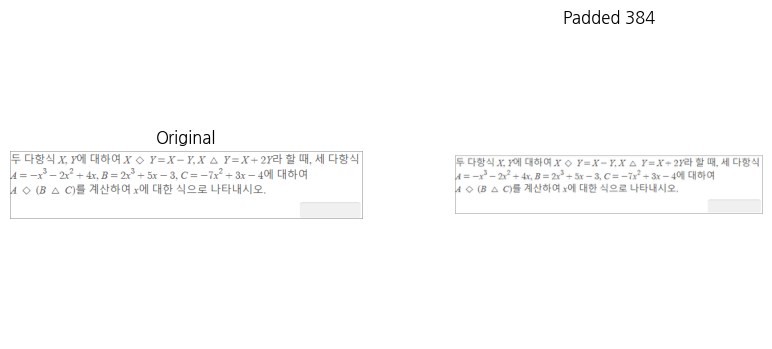

logits shape: torch.Size([1, 6])
logits: tensor([[-0.2502,  0.3257, -0.7054, -0.2126, -0.6991,  0.8013]])
0. 공통수학1__다항식: 0.1258
1. 공통수학1__방정식과부등식: 0.2237
2. 공통수학1__도형의방정식: 0.0798
3. 공통수학2__집합과명제: 0.1306
4. 공통수학2__함수: 0.0803
5. 공통수학2__경우의수: 0.3599

Top-3:
1. 공통수학2__경우의수 prob=0.3599
2. 공통수학1__방정식과부등식 prob=0.2237
3. 공통수학2__집합과명제 prob=0.1306


In [ ]:
# =========================
# 4-5. 실제 문제 이미지 1장으로 모델 입력 확인
# =========================
# 목적:
# - zip 안에 들어 있는 실제 문제 이미지를 직접 읽는다.
# - 원본 비율을 유지한 채 384x384 흰색 배경 이미지로 변환한다.
# - 변환된 이미지가 processor/model을 정상 통과하는지 확인한다.
#
# 주의:
# - 아직 학습 전 모델이므로 예측값은 의미 있는 분류 결과가 아님.
# - 여기서는 "데이터 → 이미지 → 전처리 → 모델 출력" 흐름이 깨지지 않는지만 본다.

import zipfile
from io import BytesIO

from PIL import Image
import matplotlib.pyplot as plt
import torch

# =========================
# 1. 이미지 resize + 흰색 padding 함수
# =========================

def resize_with_padding(image, size=384, fill_color="white"):
    # ViT는 정사각형 입력을 기대하므로, 먼저 RGB 이미지로 통일한다.
    image = image.convert("RGB")

    original_w, original_h = image.size

    # 원본 비율을 유지하기 위해 가로/세로 중 더 많이 줄여야 하는 비율을 선택한다.
    # 예: 긴 가로 문제 이미지는 가로를 384에 맞추고, 위아래를 흰색으로 채운다.
    scale = min(size / original_w, size / original_h)

    new_w = int(original_w * scale)
    new_h = int(original_h * scale)

    # 수식/글자가 최대한 덜 뭉개지도록 고품질 리샘플링을 사용한다.
    resized = image.resize((new_w, new_h), Image.Resampling.LANCZOS)

    # 최종 입력 크기인 384x384 흰색 캔버스를 만든다.
    canvas = Image.new("RGB", (size, size), fill_color)

    # resized 이미지를 캔버스 중앙에 배치한다.
    left = (size - new_w) // 2
    top = (size - new_h) // 2
    canvas.paste(resized, (left, top))

    return canvas

# =========================
# 2. zip에서 이미지 1장 열기
# =========================

# 우선 110 train 이미지 zip에서 첫 번째 이미지로 테스트한다.
# 이후 Dataset 클래스에서는 manifest의 image_zip_path/image_inner_path를 이용해 같은 방식으로 읽는다.
image_zip_path = PATHS["110_image_train"]

with zipfile.ZipFile(image_zip_path) as zf:
    # zip 내부 파일 중 이미지 확장자만 추린다.
    image_names = [
        name for name in zf.namelist()
        if name.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    # 가장 첫 번째 이미지를 샘플로 사용한다.
    sample_image_name = image_names[0]

    # zip 내부 파일을 bytes로 읽은 뒤 PIL Image로 연다.
    with zf.open(sample_image_name) as f:
        original_image = Image.open(BytesIO(f.read())).convert("RGB")

print("image zip:", image_zip_path)
print("sample image:", sample_image_name)
print("original size:", original_image.size)

# =========================
# 3. 384x384로 변환 후 눈으로 확인
# =========================

# 원본 비율 유지 + 흰색 padding 적용.
padded_image = resize_with_padding(original_image, size=IMAGE_SIZE)

print("padded size:", padded_image.size)

# 원본 이미지와 384 변환 이미지를 나란히 확인한다.
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(padded_image)
plt.title("Padded 384")
plt.axis("off")

plt.show()

# =========================
# 4. 실제 이미지로 모델 출력 확인
# =========================

# 현재 런타임이 GPU면 cuda, 아니면 cpu를 사용한다.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(DEVICE)
model.eval()

# processor는 PIL 이미지를 ViT 입력 텐서(pixel_values)로 바꿔준다.
inputs = processor(images=padded_image, return_tensors="pt")

# model과 입력 텐서가 같은 장치(cpu/cuda)에 있어야 한다.
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

# 지금은 학습이 아니라 forward 확인이므로 gradient 계산을 끈다.
with torch.no_grad():
    outputs = model(**inputs)

# logits는 6개 라벨 각각에 대한 원본 점수다.
logits = outputs.logits

# softmax를 적용하면 6개 점수를 합이 1인 확률 형태로 볼 수 있다.
probs = torch.softmax(logits, dim=-1)

print("logits shape:", logits.shape)
print("logits:", logits.cpu())

# =========================
# 5. 라벨별 확률 출력
# =========================

# 아직 학습 전이라 확률값은 의미 있는 예측이 아니다.
# 다만 6개 라벨이 모두 정상 출력되는지 확인할 수 있다.
for i, label in id2label.items():
    prob_value = probs[0, i].item()
    print(f"{i}. {label}: {prob_value:.4f}")

# =========================
# 6. Top-3 예측 확인
# =========================

# 확률이 가장 높은 라벨 3개를 출력한다.
# 학습 후에는 이 코드를 실제 예측 함수로 재사용할 수 있다.
top_probs, top_ids = torch.topk(probs[0], k=3)

print("\nTop-3:")
for rank, (prob, label_id) in enumerate(zip(top_probs, top_ids), start=1):
    label_id = label_id.item()
    print(f"{rank}. {id2label[label_id]} prob={prob.item():.4f}")

 - 정답은 틀렸는데, 아직 학습 전이므로 Top3 결과는 의미 있는 예측은 아님.

## Step 5. 최종 데이터셋 구성

- 아래 셀들은 Colab에서 다시 검증한 최신 manifest/split 생성 흐름이다.  
최종 학습에는 여기서 생성된 `manifest_df`, `train_df`, `valid_df`, `test_df`를 사용한다.

### 5-1. split DataFrame 확인

In [ ]:
# =========================
# 5-1. split DataFrame 확인
# =========================
# Dataset 클래스를 만들기 전에 train/valid/test 데이터프레임 이름과 컬럼을 확인한다.

for name in ["manifest_df", "train_df", "valid_df", "test_df"]:
    if name in globals():
        df = globals()[name]
        print(f"\n{name}: shape={df.shape}")
        print(df.columns.tolist())
        display(df.head(3))
    else:
        print(f"\n{name}: 없음")


manifest_df: 없음

train_df: 없음

valid_df: 없음

test_df: 없음


### 5-2. 라벨 정의와 단원 매핑 함수

In [ ]:
# =========================
# 5-2. 라벨 정의와 단원 매핑 함수
# =========================
# 목적:
# - 공통수학1/2의 세부 unit을 최종 6개 라벨로 묶는다.
# - 이후 manifest 생성 시 label_id까지 같이 만든다.

LABELS = [
    "공통수학1__다항식",
    "공통수학1__방정식과부등식",
    "공통수학1__도형의방정식",
    "공통수학2__집합과명제",
    "공통수학2__함수",
    "공통수학2__경우의수",
]

label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

def map_unit(term, unit):
    # unit은 "01" 같은 문자열로 통일해서 비교한다.
    term = int(term)
    unit = str(unit).zfill(2)

    if term == 1 and unit in ["01", "02"]:
        return "공통수학1__다항식"
    if term == 1 and unit in ["03", "04", "05", "06"]:
        return "공통수학1__방정식과부등식"
    if term == 1 and unit in ["07", "08", "09"]:
        return "공통수학1__도형의방정식"

    if term == 2 and unit in ["01", "02", "03"]:
        return "공통수학2__집합과명제"
    if term == 2 and unit in ["04", "05", "06"]:
        return "공통수학2__함수"
    if term == 2 and unit in ["07"]:
        return "공통수학2__경우의수"

    return None

print("labels:")
for i, label in id2label.items():
    print(i, label)

labels:
0 공통수학1__다항식
1 공통수학1__방정식과부등식
2 공통수학1__도형의방정식
3 공통수학2__집합과명제
4 공통수학2__함수
5 공통수학2__경우의수


### 5-3. manifest 생성

In [ ]:
# =========================
# 5-3. label zip + image zip으로 manifest 생성
# =========================
# 목적:
# - 라벨 JSON과 실제 이미지 파일을 question_filename 기준으로 매칭한다.
# - 각 row에 이미지 zip 경로, zip 내부 이미지 경로, 라벨 정보를 저장한다.
#
# 중요:
# - JSON은 utf-8-sig로 읽는다. 일부 파일에 BOM이 있을 수 있음.
# - 이미지는 zip을 풀지 않고 zip 내부 경로만 저장한다.

import json
import zipfile
import re
from pathlib import Path

import pandas as pd
from tqdm.auto import tqdm

def normalize_question_text(text):
    # 중복 split 방지를 위해 공백을 정규화한 문제 텍스트를 만든다.
    if text is None:
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def get_image_index(image_zip_path):
    # zip 내부 이미지 파일을 basename 기준으로 찾기 쉽게 만든다.
    image_index = {}

    with zipfile.ZipFile(image_zip_path) as zf:
        for name in zf.namelist():
            if name.lower().endswith((".png", ".jpg", ".jpeg")):
                image_index[Path(name).name] = name

    return image_index

def build_manifest_part(source_name, label_zip_path, image_zip_path):
    # 하나의 label zip / image zip 쌍에서 manifest row를 만든다.
    image_index = get_image_index(image_zip_path)
    rows = []

    with zipfile.ZipFile(label_zip_path) as zf:
        json_names = [
            name for name in zf.namelist()
            if name.lower().endswith(".json")
        ]

        for json_name in tqdm(json_names, desc=source_name):
            data = json.loads(zf.read(json_name).decode("utf-8-sig"))

            question_filename = data.get("question_filename")
            sample_id = data.get("id")

            question_info = data.get("question_info", [{}])[0]
            ocr_info = data.get("OCR_info", [{}])[0]

            term = question_info.get("question_term")
            unit = question_info.get("question_unit")
            question_text = ocr_info.get("question_text")

            label = map_unit(term, unit)
            image_inner_path = image_index.get(question_filename)

            rows.append({
                "source": source_name,
                "sample_id": sample_id,
                "label_json_path": json_name,
                "question_filename": question_filename,
                "image_zip_path": str(image_zip_path),
                "image_inner_path": image_inner_path,
                "term": term,
                "unit": str(unit).zfill(2),
                "question_text": question_text,
                "question_text_norm": normalize_question_text(question_text),
                "label": label,
                "label_id": label2id[label] if label in label2id else None,
                "image_found": image_inner_path is not None,
            })

    return rows

manifest_rows = []

manifest_rows += build_manifest_part(
    "110_train",
    PATHS["110_label_train"],
    PATHS["110_image_train"],
)

manifest_rows += build_manifest_part(
    "110_valid",
    PATHS["110_label_valid"],
    PATHS["110_image_valid"],
)

manifest_rows += build_manifest_part(
    "111_train",
    PATHS["111_label_train"],
    PATHS["111_image_train"],
)

manifest_rows += build_manifest_part(
    "111_valid",
    PATHS["111_label_valid"],
    PATHS["111_image_valid"],
)

manifest_df = pd.DataFrame(manifest_rows)

print("manifest rows:", len(manifest_df))
display(manifest_df.head())

110_train:   0%|          | 0/3001 [00:00<?, ?it/s]

110_valid:   0%|          | 0/314 [00:00<?, ?it/s]

111_train:   0%|          | 0/5811 [00:00<?, ?it/s]

111_valid:   0%|          | 0/647 [00:00<?, ?it/s]

manifest rows: 9773


,source,sample_id,label_json_path,question_filename,image_zip_path,image_inner_path,term,unit,question_text,question_text_norm,label,label_id,image_found
0,110_train,25766_84187,/H_1_01_25766_84187.json,H_1_01_25766_84187.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25766_84187.png,1,01,"두 다항식 $A=3x^3-3x^2+5x$, $B=x^2-3x+6$에 대하여 $A-3...","두 다항식 $A=3x^3-3x^2+5x$, $B=x^2-3x+6$에 대하여 $A-3...",공통수학1__다항식,0,True
1,110_train,25790_84306,/H_1_01_25790_84306.json,H_1_01_25790_84306.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25790_84306.png,1,01,"두 다항식 $A$, $B$에 대하여 $A+B=8x^2-6xy+y^2$, $2A-B=...","두 다항식 $A$, $B$에 대하여 $A+B=8x^2-6xy+y^2$, $2A-B=...",공통수학1__다항식,0,True
2,110_train,25768_84195,/H_1_01_25768_84195.json,H_1_01_25768_84195.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25768_84195.png,1,01,"두 다항식 $A=4x^2-2xy+y^2$, $B=-x^2-3xy+4y^2$에 대하여...","두 다항식 $A=4x^2-2xy+y^2$, $B=-x^2-3xy+4y^2$에 대하여...",공통수학1__다항식,0,True
3,110_train,25802_84340,/H_1_01_25802_84340.json,H_1_01_25802_84340.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25802_84340.png,1,01,다항식 $(x^2+2xy-y^2)(-x+3y)$를 전개하시오.,다항식 $(x^2+2xy-y^2)(-x+3y)$를 전개하시오.,공통수학1__다항식,0,True
4,110_train,25766_84188,/H_1_01_25766_84188.json,H_1_01_25766_84188.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25766_84188.png,1,01,"세 다항식 $A=2x^3-4x^2+5$, $B=x^2+x-6$, $C=4x^2+5x...","세 다항식 $A=2x^3-4x^2+5$, $B=x^2+x-6$, $C=4x^2+5x...",공통수학1__다항식,0,True


### 5-4.  품질 검사 + split

In [ ]:
# =========================
# 5-4. manifest 품질 검사와 train/valid/test split
# =========================
# 목적:
# - 이미지 매칭 실패, 라벨 매핑 실패, 빈 문제 텍스트를 확인한다.
# - 같은 question_text_norm이 여러 split으로 갈라지지 않게 group split 한다.

from sklearn.model_selection import GroupShuffleSplit

# =========================
# 1. 품질 검사
# =========================

print("manifest rows:", len(manifest_df)) # 학습에 사용할 샘플 목록의 행 개수
print("image matching failed:", (~manifest_df["image_found"]).sum())
print("label mapping failed:", manifest_df["label"].isna().sum())
print("empty question_text_norm:", (manifest_df["question_text_norm"] == "").sum())

usable_df = manifest_df[
    manifest_df["image_found"]
    & manifest_df["label"].notna()
    & (manifest_df["question_text_norm"] != "")
].copy()

usable_df["label_id"] = usable_df["label_id"].astype(int)

print("usable rows:", len(usable_df))

print("\nlabel distribution:")
display(usable_df["label"].value_counts())

# =========================
# 2. 중복 검사
# =========================

print("\nduplicate checks:")
print("sample_id duplicated:", usable_df["sample_id"].duplicated().sum())
print("question_filename duplicated:", usable_df["question_filename"].duplicated().sum())
print("question_text_norm duplicated:", usable_df["question_text_norm"].duplicated().sum())

# =========================
# 3. group split
# =========================
# 1차: 전체에서 test 10% 분리
# 2차: 남은 90%에서 valid를 약 10%로 분리

SEED = 42

gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.10,
    random_state=SEED,
)

train_valid_idx, test_idx = next(
    gss_test.split(
        usable_df,
        groups=usable_df["question_text_norm"],
    )
)

train_valid_df = usable_df.iloc[train_valid_idx].copy()
test_df = usable_df.iloc[test_idx].copy()

gss_valid = GroupShuffleSplit(
    n_splits=1,
    test_size=0.1111,
    random_state=SEED,
)

train_idx, valid_idx = next(
    gss_valid.split(
        train_valid_df,
        groups=train_valid_df["question_text_norm"],
    )
)

train_df = train_valid_df.iloc[train_idx].copy()
valid_df = train_valid_df.iloc[valid_idx].copy()

# index를 정리해서 Dataset에서 iloc 사용이 편하게 만든다.
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nsplit sizes:")
print("train:", len(train_df))
print("valid:", len(valid_df))
print("test :", len(test_df))
print("total:", len(train_df) + len(valid_df) + len(test_df))

print("\ntrain label distribution:")
display(train_df["label"].value_counts())

print("\nvalid label distribution:")
display(valid_df["label"].value_counts())

print("\ntest label distribution:")
display(test_df["label"].value_counts())

# =========================
# 4. group leakage 확인
# =========================
# 같은 문제 텍스트가 train/valid/test에 동시에 들어가면 안 된다.

train_groups = set(train_df["question_text_norm"])
valid_groups = set(valid_df["question_text_norm"])
test_groups = set(test_df["question_text_norm"])

print("\ngroup overlap:")
print("train-valid:", len(train_groups & valid_groups))
print("train-test :", len(train_groups & test_groups))
print("valid-test :", len(valid_groups & test_groups))

manifest rows: 9773
image matching failed: 0
label mapping failed: 0
empty question_text_norm: 0
usable rows: 9773

label distribution:


,count
label,
공통수학1__방정식과부등식,2233
공통수학2__집합과명제,1794
공통수학2__함수,1695
공통수학1__도형의방정식,1667
공통수학1__다항식,1400
공통수학2__경우의수,984



duplicate checks:
sample_id duplicated: 0
question_filename duplicated: 0
question_text_norm duplicated: 101

split sizes:
train: 7798
valid: 996
test : 979
total: 9773

train label distribution:


,count
label,
공통수학1__방정식과부등식,1784
공통수학2__집합과명제,1456
공통수학2__함수,1358
공통수학1__도형의방정식,1340
공통수학1__다항식,1097
공통수학2__경우의수,763



valid label distribution:


,count
label,
공통수학1__방정식과부등식,235
공통수학1__도형의방정식,173
공통수학2__집합과명제,164
공통수학2__함수,157
공통수학1__다항식,141
공통수학2__경우의수,126



test label distribution:


,count
label,
공통수학1__방정식과부등식,214
공통수학2__함수,180
공통수학2__집합과명제,174
공통수학1__다항식,162
공통수학1__도형의방정식,154
공통수학2__경우의수,95



group overlap:
train-valid: 0
train-test : 0
valid-test : 0


  - 전체 샘플 9,773개
  - 사용 가능 샘플 9,773개
  - 이미지/라벨 매칭 실패 0개
  - split 간 중복 문제 텍스트 누수 0개

### 5-5. 전체 라벨 분포 시각화

,count
label,
공통수학1__다항식,1400
공통수학1__방정식과부등식,2233
공통수학1__도형의방정식,1667
공통수학2__집합과명제,1794
공통수학2__함수,1695
공통수학2__경우의수,984


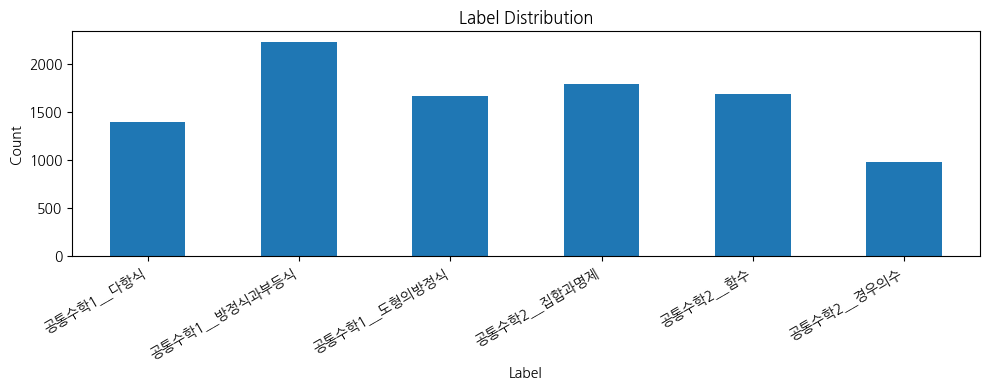

In [ ]:
# =========================
# 5-5. 전체 라벨 분포 시각화
# =========================
# 목적:
# - 전체 사용 가능 데이터에서 6개 라벨이 얼마나 분포되어 있는지 확인한다.
# - 특정 라벨이 너무 적으면 학습 성능이나 평가 안정성이 낮아질 수 있다.
#
# 전제:
# - 5-4에서 usable_df가 생성되어 있어야 한다.

import matplotlib.pyplot as plt

# =========================
# 1. 전체 라벨 개수 계산
# =========================

label_counts = usable_df["label"].value_counts().reindex(LABELS)

display(label_counts)

# =========================
# 2. bar chart 출력
# =========================

plt.figure(figsize=(10, 4))
label_counts.plot(kind="bar")

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 5-6. split별 라벨 분포 시각화

,train,valid,test
label,,,
공통수학1__다항식,1097,141,162
공통수학1__방정식과부등식,1784,235,214
공통수학1__도형의방정식,1340,173,154
공통수학2__집합과명제,1456,164,174
공통수학2__함수,1358,157,180
공통수학2__경우의수,763,126,95


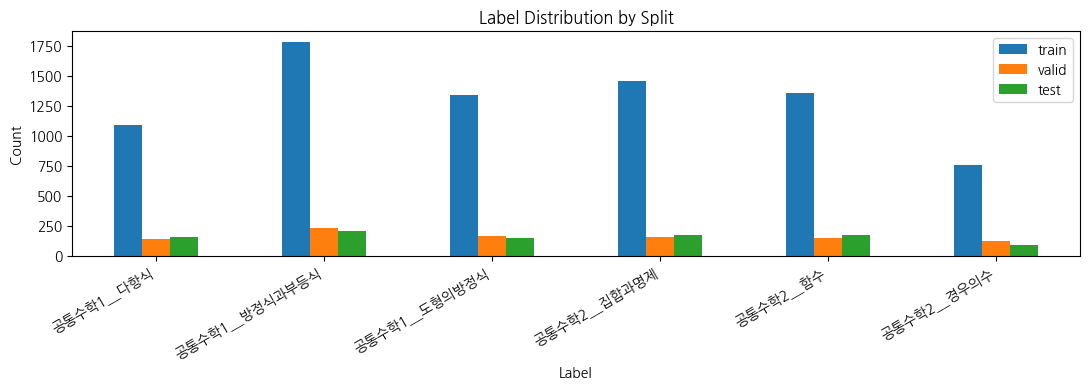

In [ ]:
# =========================
# 5-6. split별 라벨 분포 시각화
# =========================
# 목적:
# - train / valid / test에 라벨이 어떻게 나뉘었는지 확인한다.
# - 특정 split에 특정 라벨이 과하게 몰렸는지 확인한다.
#
# 전제:
# - 5-4에서 train_df, valid_df, test_df가 생성되어 있어야 한다.

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. split별 라벨 개수 표 생성
# =========================

split_label_counts = pd.DataFrame({
    "train": train_df["label"].value_counts().reindex(LABELS),
    "valid": valid_df["label"].value_counts().reindex(LABELS),
    "test": test_df["label"].value_counts().reindex(LABELS),
}).fillna(0).astype(int)

display(split_label_counts)

# =========================
# 2. split별 라벨 분포 bar chart
# =========================

split_label_counts.plot(kind="bar", figsize=(11, 4))

plt.title("Label Distribution by Split")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 5-7. 라벨별 실제 이미지 샘플 보기

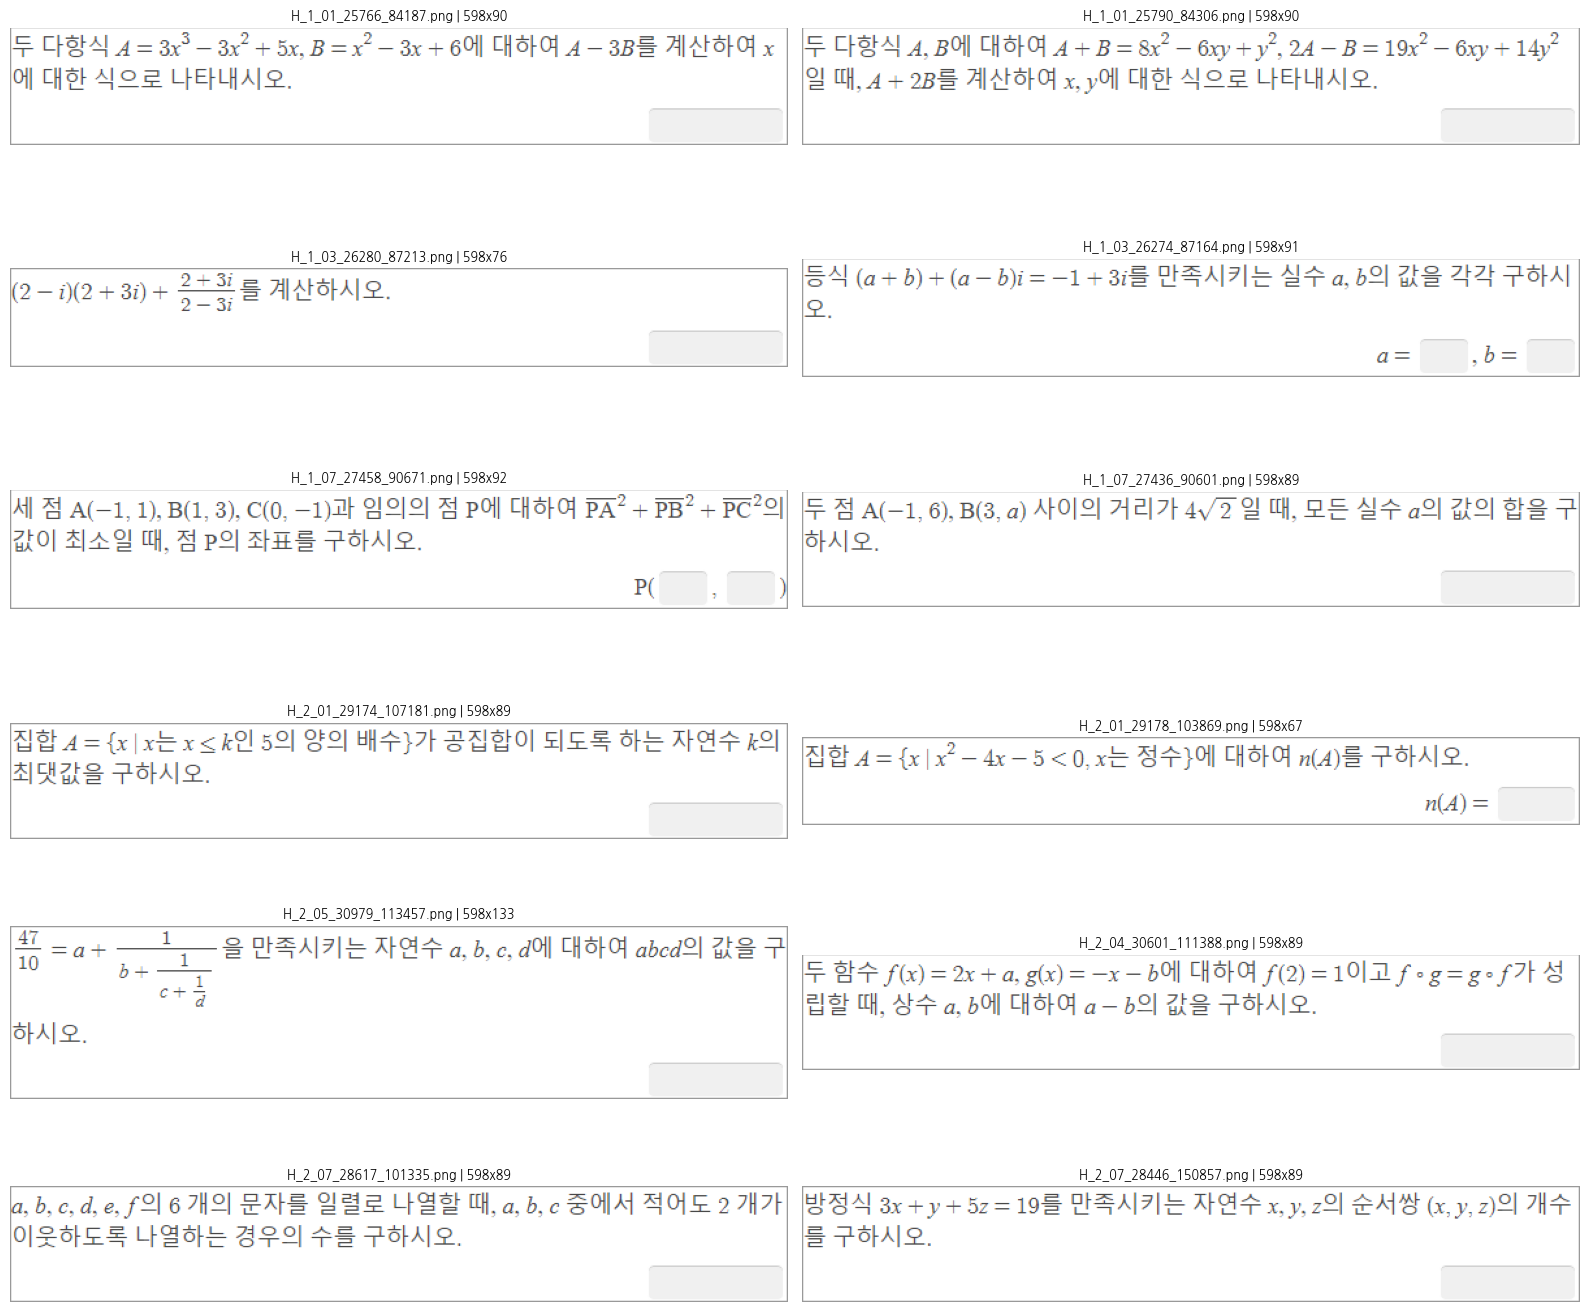

In [ ]:
# =========================
# 5-7. 라벨별 실제 이미지 샘플 크게 보기
# =========================
# 목적:
# - 각 라벨의 실제 문제 이미지를 원본 비율 그대로 크게 확인한다.
# - 학습 입력용 384 padding 이미지는 문제 영역이 작아 보이므로,
#   여기서는 시각화용으로 padding 없이 원본 이미지를 사용한다.
#
# 전제:
# - 5-4에서 train_df가 생성되어 있어야 한다.

import zipfile
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

# =========================
# 1. manifest row에서 이미지 읽는 함수
# =========================

def load_image_from_row(row):
    # row에 저장된 zip 경로와 zip 내부 이미지 경로로 실제 이미지를 읽는다.
    with zipfile.ZipFile(row["image_zip_path"]) as zf:
        with zf.open(row["image_inner_path"]) as f:
            image = Image.open(BytesIO(f.read())).convert("RGB")

    return image

# =========================
# 2. 라벨별 샘플 이미지 출력
# =========================
# samples_per_label:
# - 라벨마다 몇 장씩 볼지 설정한다.
# - 문제 내용 확인 목적이면 1~2장이 보기 좋다.

samples_per_label = 2

fig, axes = plt.subplots(
    nrows=len(LABELS),
    ncols=samples_per_label,
    figsize=(16, 2.4 * len(LABELS)),
)

for row_idx, label in enumerate(LABELS):
    # 각 라벨에서 앞쪽 샘플 몇 개를 선택한다.
    label_rows = train_df[train_df["label"] == label].head(samples_per_label)

    for col_idx, (_, row) in enumerate(label_rows.iterrows()):
        image = load_image_from_row(row)

        ax = axes[row_idx, col_idx]
        ax.imshow(image)
        ax.axis("off")

        # 왼쪽 첫 칸에 라벨명을 표시한다.
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=11, rotation=0, labelpad=80, va="center")

        # 각 이미지의 원본 크기도 같이 표시한다.
        ax.set_title(
            f"{row['question_filename']} | {image.size[0]}x{image.size[1]}",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

## Step 6. Dataset 준비

###  Step 6-0. train 전용 이미지 증강 설정

In [ ]:
# # =========================
# # 6-0. train 전용 이미지 증강 설정
# # =========================
# # 목적:
# # - 실제 촬영 사진처럼 약간 흐림, 밝기 차이, 기울어짐이 있는 입력에 강하게 만든다.
# # - train에만 증강을 적용하고, valid/test에는 적용하지 않는다.
# #
# # 주의:
# # - 너무 강한 증강은 수식/글자를 망가뜨릴 수 있으므로 약하게 시작한다.
# # - ToTensor/Normalize는 넣지 않는다. processor가 처리한다.

# from torchvision import transforms

# train_transform = transforms.Compose([
#     transforms.RandomApply([
#         transforms.ColorJitter(
#             brightness=0.20,
#             contrast=0.20,
#             saturation=0.05,
#             hue=0.02,
#         )
#     ], p=0.60),

#     transforms.RandomApply([
#         transforms.GaussianBlur(
#             kernel_size=3,
#             sigma=(0.1, 1.0),
#         )
#     ], p=0.20),

#     transforms.RandomRotation(
#         degrees=3,
#         fill=255,
#     ),

#     transforms.RandomApply([
#         transforms.RandomAffine(
#             degrees=0,
#             translate=(0.03, 0.03),
#             scale=(0.95, 1.05),
#             shear=2,
#             fill=255,
#         )
#     ], p=0.30),
# ])

# eval_transform = None

# print("train_transform ready")

### 6-1. Dataset 클래스

In [ ]:
# =========================
# 6-1. PyTorch Dataset 클래스 만들기 - train 증강 적용 버전
# =========================
# 목적:
# - train_df / valid_df / test_df의 각 row를 학습용 샘플로 변환한다.
# - zip 내부 이미지를 읽고, train에는 약한 이미지 증강을 적용한다.
# - 이후 384x384 padding resize를 적용한다.
# - processor를 이용해 ViT 입력 텐서(pixel_values)를 만든다.
# - labels에는 정답 label_id를 넣는다.
#
# 핵심:
# - train_dataset에만 증강을 적용한다.
# - valid_dataset / test_dataset에는 증강을 적용하지 않는다.

import zipfile
from io import BytesIO

from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms


# =========================
# 1. train 전용 이미지 증강 설정
# =========================
# 목적:
# - 실제 촬영 이미지처럼 밝기/대비 차이, 약한 흔들림, 약한 회전/이동을 학습에 반영한다.
# - 너무 강한 증강은 수식과 글자를 망가뜨릴 수 있으므로 약하게 시작한다.
# - ToTensor/Normalize는 넣지 않는다. processor가 처리한다.

# train_transform = transforms.Compose([
#     transforms.RandomApply([
#         transforms.ColorJitter(
#             brightness=0.20,
#             contrast=0.20,
#             saturation=0.05,
#             hue=0.02,
#         )
#     ], p=0.60),

#     transforms.RandomApply([
#         transforms.GaussianBlur(
#             kernel_size=3,
#             sigma=(0.1, 1.0),
#         )
#     ], p=0.20),

#     transforms.RandomRotation(
#         degrees=3,
#         fill=(255, 255, 255),
#     ),

#     transforms.RandomApply([
#         transforms.RandomAffine(
#             degrees=0,
#             translate=(0.03, 0.03),
#             scale=(0.95, 1.05),
#             shear=2,
#             fill=(255, 255, 255),
#         )
#     ], p=0.30),
# ])

train_transform = transforms.Compose([
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.08,
            contrast=0.08,
        )
    ], p=0.30),

    transforms.RandomRotation(
        degrees=1,
        fill=(255, 255, 255),
    ),
])

eval_transform = None


# =========================
# 2. zip 파일 핸들 캐시
# =========================
# - zip 파일을 한 번만 열고 재사용한다.
# - image_inner_path가 "/파일명.png" 또는 "파일명.png"처럼 들어와도 실제 zip entry를 찾아 연다.
# - zf.open()에는 반드시 zip 안에 저장된 원본 entry name을 사용한다.
from pathlib import PurePosixPath

class ZipImageReader:
    def __init__(self):
        self.zip_cache = {}
        self.entry_cache = {}

    def get_zip(self, zip_path):
        zip_path = str(zip_path)

        if zip_path not in self.zip_cache:
            self.zip_cache[zip_path] = zipfile.ZipFile(zip_path)

        return self.zip_cache[zip_path]

    def normalize_name(self, name):
        return str(name).replace("\\", "/").lstrip("/")

    def get_entry_index(self, zip_path):
        zip_path = str(zip_path)

        if zip_path not in self.entry_cache:
            zf = self.get_zip(zip_path)

            raw_names = [
                info.filename
                for info in zf.infolist()
                if not info.is_dir()
            ]

            norm_to_raw = {}
            filename_to_raw = {}

            for raw_name in raw_names:
                norm_name = self.normalize_name(raw_name)
                filename = PurePosixPath(norm_name).name

                norm_to_raw[norm_name] = raw_name
                filename_to_raw.setdefault(filename, []).append(raw_name)

            self.entry_cache[zip_path] = {
                "raw_names": raw_names,
                "norm_to_raw": norm_to_raw,
                "filename_to_raw": filename_to_raw,
            }

        return self.entry_cache[zip_path]

    def resolve_entry(self, zip_path, inner_path):
        norm_inner_path = self.normalize_name(inner_path)
        target_filename = PurePosixPath(norm_inner_path).name

        index = self.get_entry_index(zip_path)

        # 1순위: 정규화한 전체 경로가 일치
        if norm_inner_path in index["norm_to_raw"]:
            return index["norm_to_raw"][norm_inner_path]

        # 2순위: 파일명만 일치
        matches = index["filename_to_raw"].get(target_filename, [])

        if len(matches) == 1:
            return matches[0]

        if len(matches) > 1:
            raise ValueError(
                f"같은 파일명이 zip 안에 여러 개 있습니다: {target_filename}\n"
                f"matches={matches[:20]}"
            )

        raise FileNotFoundError(
            f"zip 안에서 이미지를 찾지 못했습니다.\n"
            f"zip_path={zip_path}\n"
            f"inner_path={inner_path}\n"
            f"target_filename={target_filename}\n"
            f"sample_names={index['raw_names'][:20]}"
        )

    def read_image(self, zip_path, inner_path):
        zf = self.get_zip(zip_path)
        raw_entry = self.resolve_entry(zip_path, inner_path)

        with zf.open(raw_entry) as f:
            image = Image.open(BytesIO(f.read())).convert("RGB")

        return image

    def close(self):
        for zf in self.zip_cache.values():
            zf.close()

        self.zip_cache.clear()
        self.entry_cache.clear()

# =========================
# 3. ODAP 이미지 분류 Dataset
# =========================

class OdapImageDataset(Dataset):
    def __init__(self, df, processor, image_size=384, transform=None):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.image_size = image_size
        self.transform = transform
        self.reader = ZipImageReader()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_zip_path = row["image_zip_path"]
        image_inner_path = row["image_inner_path"]
        label_id = int(row["label_id"])

        # zip 내부에서 원본 이미지를 읽는다.
        image = self.reader.read_image(
            image_zip_path,
            image_inner_path,
        )

        # train에만 증강 적용
        if self.transform is not None:
            image = self.transform(image)

        # 원본 비율 유지 + 흰색 padding으로 384x384 입력 이미지를 만든다.
        image = resize_with_padding(
            image,
            size=self.image_size,
            fill_color="white",
        )

        encoded = self.processor(
            images=image,
            return_tensors="pt",
        )

        pixel_values = encoded["pixel_values"].squeeze(0)

        return {
            "pixel_values": pixel_values,
            "labels": torch.tensor(label_id, dtype=torch.long),
        }


# =========================
# 4. Dataset 객체 생성
# =========================
# 핵심:
# - train_dataset만 train_transform 적용
# - valid/test는 원본 평가를 위해 증강 없음

train_dataset = OdapImageDataset(
    train_df,
    processor=processor,
    image_size=IMAGE_SIZE,
    transform=train_transform,
)

valid_dataset = OdapImageDataset(
    valid_df,
    processor=processor,
    image_size=IMAGE_SIZE,
    transform=eval_transform,
)

test_dataset = OdapImageDataset(
    test_df,
    processor=processor,
    image_size=IMAGE_SIZE,
    transform=eval_transform,
)

print("train_dataset:", len(train_dataset))
print("valid_dataset:", len(valid_dataset))
print("test_dataset :", len(test_dataset))

train_dataset: 7798
valid_dataset: 996
test_dataset : 979


### 6-2. Dataset 샘플 1개 확인

In [ ]:
# =========================
# 6-2. Dataset 샘플 1개 확인
# =========================
# 목적:
# - Dataset이 실제로 pixel_values와 labels를 정상 반환하는지 확인한다.
# - pixel_values shape이 [3, 384, 384]이면 ViT 입력 형식이 맞다.

sample = train_dataset[0]

print("sample keys:", sample.keys())
print("pixel_values shape:", sample["pixel_values"].shape)
print("pixel_values dtype:", sample["pixel_values"].dtype)
print("labels:", sample["labels"])
print("label name:", id2label[int(sample["labels"])])

sample keys: dict_keys(['pixel_values', 'labels'])
pixel_values shape: torch.Size([3, 384, 384])
pixel_values dtype: torch.float32
labels: tensor(0)
label name: 공통수학1__다항식


### 6-3. DataLoader batch 확인

- 작은 batch로 loss 계산 확인 단계
- 학습 코드를 만들기 전에, 여러 샘플이 batch로 잘 묶이고 모델이 loss까지 계산하는지 먼저 확인

In [ ]:
# =========================
# 6-3. DataLoader batch 확인
# =========================
# 목적:
# - Dataset 샘플 여러 개가 batch로 잘 묶이는지 확인한다.
# - pixel_values shape이 [batch_size, 3, 384, 384]이면 정상.
#
# 주의:
# - zip 파일을 읽는 Dataset이므로 우선 num_workers=0으로 둔다.
# - CPU 세션에서는 batch_size를 작게 잡는다.

from torch.utils.data import DataLoader

# =========================
# 1. 작은 batch_size로 DataLoader 생성
# =========================

BATCH_SIZE_CHECK = 4

train_loader_check = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_CHECK,
    shuffle=True,
    num_workers=0,
)

# =========================
# 2. batch 하나 꺼내서 구조 확인
# =========================

batch = next(iter(train_loader_check))

print("batch keys:", batch.keys())
print("pixel_values shape:", batch["pixel_values"].shape)
print("pixel_values dtype:", batch["pixel_values"].dtype)
print("labels shape:", batch["labels"].shape)
print("labels:", batch["labels"])

# =========================
# 3. label_id를 라벨 이름으로 확인
# =========================

print("\nlabel names:")
for label_id in batch["labels"].tolist():
    print(label_id, id2label[label_id])

batch keys: dict_keys(['pixel_values', 'labels'])
pixel_values shape: torch.Size([4, 3, 384, 384])
pixel_values dtype: torch.float32
labels shape: torch.Size([4])
labels: tensor([5, 2, 5, 0])

label names:
5 공통수학2__경우의수
2 공통수학1__도형의방정식
5 공통수학2__경우의수
0 공통수학1__다항식


```
pixel_values shape: torch.Size([4, 3, 384, 384])
labels shape: torch.Size([4])
```
- 이미지 4장이 한 batch로 묶였고,
각 이미지는 ViT 입력 형식인 3 x 384 x 384 텐서이고,
정답 라벨도 4개가 같이 묶임.

### 6-4. 작은 batch로 모델 loss 계산 확인

In [ ]:
# =========================
# 6-4. 작은 batch로 모델 loss 계산 확인
# =========================
# 목적:
# - 실제 batch를 모델에 넣었을 때 forward가 정상 동작하는지 확인한다.
# - labels를 같이 넣으면 모델이 classification loss를 계산해준다.
#
# 주의:
# - 아직 학습은 하지 않는다.
# - 여기서는 gradient update 없이 loss 값이 나오는지만 확인한다.

import torch

# =========================
# 1. 현재 장치 설정
# =========================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(DEVICE)
model.eval()

print("DEVICE:", DEVICE)

# =========================
# 2. batch를 model과 같은 장치로 이동
# =========================

batch_on_device = {
    key: value.to(DEVICE)
    for key, value in batch.items()
}

# =========================
# 3. forward 실행
# =========================
# labels가 있으면 outputs.loss가 자동으로 계산된다.
# logits shape은 [batch_size, 6]이어야 한다.

with torch.no_grad():
    outputs = model(**batch_on_device)

print("loss:", outputs.loss.item())           # loss
print("logits shape:", outputs.logits.shape)  # 모델 출력 shape

# =========================
# 4. batch 안의 첫 번째 이미지 예측값 확인
# =========================
# 아직 학습 전이라 예측이 맞는지는 중요하지 않다.
# 출력 구조와 라벨 연결이 맞는지만 확인한다.

probs = torch.softmax(outputs.logits, dim=-1)

first_true_id = batch_on_device["labels"][0].item()
first_pred_id = probs[0].argmax().item()

print("\nfirst sample:")
print("true:", first_true_id, id2label[first_true_id])
print("pred:", first_pred_id, id2label[first_pred_id])
print("pred prob:", probs[0, first_pred_id].item())

DEVICE: cuda
loss: 1.4006879329681396
logits shape: torch.Size([4, 6])

first sample:
true: 5 공통수학2__경우의수
pred: 5 공통수학2__경우의수
pred prob: 0.3559238314628601


## Step 7. 학습 준비

### 7-1. 평가 metric 정의

In [ ]:
# =========================
# 7-1. 평가 metric 정의
# =========================
# 목적:
# - 학습 중 valid set에서 accuracy를 계산한다.
# - Trainer가 예측 logits와 정답 labels를 받아 metric을 계산할 수 있게 한다.
#
# 설명:
# - logits는 모델이 낸 6개 라벨 점수다.
# - argmax로 가장 높은 점수의 라벨을 예측값으로 사용한다.
# - accuracy는 전체 샘플 중 정답을 맞춘 비율이다.

import numpy as np
import evaluate

# =========================
# 1. accuracy metric 로드
# =========================

accuracy_metric = evaluate.load("accuracy")

# =========================
# 2. Trainer용 metric 함수
# =========================

def compute_metrics(eval_pred):
    # eval_pred는 Trainer가 넘겨주는 예측 결과와 정답이다.
    logits, labels = eval_pred

    # 6개 라벨 점수 중 가장 큰 index를 예측 라벨로 사용한다.
    predictions = np.argmax(logits, axis=-1)

    # accuracy 계산 결과는 {"accuracy": 값} 형태로 반환된다.
    return accuracy_metric.compute(
        predictions=predictions,
        references=labels,
    )

# =========================
# 3. metric 함수 간단 확인
# =========================
# 가짜 logits/labels로 accuracy 계산이 되는지 확인한다.

dummy_logits = np.array([
    [0.1, 0.9, 0.0, 0.0, 0.0, 0.0],  # pred = 1
    [0.8, 0.1, 0.0, 0.0, 0.0, 0.0],  # pred = 0
    [0.1, 0.2, 0.7, 0.0, 0.0, 0.0],  # pred = 2
])

dummy_labels = np.array([1, 2, 2])

metric_result = compute_metrics((dummy_logits, dummy_labels))

print(metric_result)

{'accuracy': 0.6666666666666666}


### 7-2. TrainingArguments 설정

In [ ]:
# =========================
# 7-2. TrainingArguments 설정
# =========================
# 목적:
# - Hugging Face Trainer가 사용할 학습 설정을 정의한다.
# - 오늘 CPU 세션에서는 설정만 준비하고, 전체 학습은 GPU 세션에서 실행한다.
#
# 주요 설정:
# - output_dir: 모델 checkpoint와 로그 저장 위치
# - eval_strategy: epoch마다 valid 평가
# - save_strategy: epoch마다 checkpoint 저장
# - load_best_model_at_end: valid accuracy 기준으로 가장 좋은 모델 로드
#
# 주의:
# - Colab CPU에서는 전체 학습을 실행하지 않는다.
# - GPU 세션에서는 batch size를 상황에 맞게 조정할 수 있다.

from transformers import TrainingArguments
from pathlib import Path
import torch

# =========================
# 1. 출력 폴더 설정
# =========================
# Drive에도 결과를 남기고 싶으면 /content/drive/MyDrive/... 경로를 사용한다.

OUTPUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/odap_vit_mvp_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)

# =========================
# 2. CPU/GPU에 따른 기본 batch size 설정
# =========================
# GPU에서는 384 이미지라 batch size 8부터 시작한다.
# 메모리 부족이 나면 4로 낮추면 된다.

IS_GPU = torch.cuda.is_available()

if IS_GPU:
    TRAIN_BATCH_SIZE = 8
    EVAL_BATCH_SIZE = 8
    FP16 = True
else:
    TRAIN_BATCH_SIZE = 2
    EVAL_BATCH_SIZE = 2
    FP16 = False

print("IS_GPU:", IS_GPU)
print("TRAIN_BATCH_SIZE:", TRAIN_BATCH_SIZE)
print("EVAL_BATCH_SIZE:", EVAL_BATCH_SIZE)
print("FP16:", FP16)

# =========================
# 3. TrainingArguments 생성
# =========================

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),

    # 학습 기본값
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,

    # 평가/저장 전략
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,

    # 가장 좋은 모델 선택 기준
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    # 로그 설정
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",

    # Colab GPU 사용 시 fp16 사용
    fp16=FP16,

    # 재현성
    seed=SEED,

    # DataLoader 설정
    dataloader_num_workers=0,
    remove_unused_columns=False,
)

print("TrainingArguments OK.")

OUTPUT_DIR: /content/drive/MyDrive/Colab Notebooks/odap_vit_mvp_output
IS_GPU: True
TRAIN_BATCH_SIZE: 8
EVAL_BATCH_SIZE: 8
FP16: True
TrainingArguments OK.


### 7-3. Trainer 생성

In [ ]:
# =========================
# 7-3. Trainer 생성
# =========================
# 목적:
# - model, training_args, train/valid Dataset, metric 함수를 묶어서 Trainer를 만든다.
# - Trainer는 이후 trainer.train(), trainer.evaluate()로 학습/평가를 실행한다.
#
# 주의:
# - 이 셀은 Trainer 객체만 생성한다.
# - 실제 학습은 trainer.train()을 호출해야 시작된다.

from transformers import Trainer

# =========================
# 1. Trainer 객체 생성
# =========================
# train_dataset: 학습에 사용할 데이터
# eval_dataset : 학습 중 평가에 사용할 valid 데이터
# compute_metrics: valid 평가 시 accuracy 계산 함수

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer created.")
print("train samples:", len(train_dataset))
print("valid samples:", len(valid_dataset))

Trainer created.
train samples: 7798
valid samples: 996


### 7-4. 소량 subset 학습 테스트

In [ ]:
# =========================
# 7-4. 소량 subset 학습 테스트
# =========================
# 목적:
# - 전체 학습 전에 Trainer의 train 루프가 정상 동작하는지 아주 작게 확인한다.
# - CPU 세션에서는 train 16개 / valid 8개 / max_steps=1만 실행한다.
#
# 주의:
# - 이 테스트는 성능을 보는 학습이 아니다.
# - 모델이 1 step 업데이트되므로, 전체 학습 전에는 모델을 다시 로드하는 것이 깔끔하다.
# - CPU에서는 느릴 수 있다. 오래 걸리면 중단해도 된다.

from torch.utils.data import Subset
from transformers import Trainer, TrainingArguments
from pathlib import Path
import torch

# =========================
# 1. 아주 작은 subset 생성
# =========================

small_train_dataset = Subset(train_dataset, list(range(16)))
small_valid_dataset = Subset(valid_dataset, list(range(8)))

print("small_train_dataset:", len(small_train_dataset))
print("small_valid_dataset:", len(small_valid_dataset))

# =========================
# 2. smoke train용 출력 폴더
# =========================

SMOKE_OUTPUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/odap_vit_smoke_output")
SMOKE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# 3. smoke train용 TrainingArguments
# =========================
# max_steps=1 이므로 batch 하나만 학습하고 종료한다.
# save_strategy="no"로 checkpoint 저장 시간을 줄인다.

smoke_training_args = TrainingArguments(
    output_dir=str(SMOKE_OUTPUT_DIR),

    max_steps=1,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    eval_strategy="no",
    save_strategy="no",

    logging_strategy="steps",
    logging_steps=1,
    report_to="none",

    fp16=False,
    seed=SEED,
    dataloader_num_workers=0,
    remove_unused_columns=False,
)

# =========================
# 4. smoke Trainer 생성
# =========================

smoke_trainer = Trainer(
    model=model,
    args=smoke_training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_valid_dataset,
    compute_metrics=compute_metrics,
)

# =========================
# 5. 1 step 학습 실행
# =========================
# 여기서부터 실제로 아주 작은 학습이 1 step 진행된다.

smoke_train_result = smoke_trainer.train()

print("Smoke train done.")
print(smoke_train_result)

small_train_dataset: 16
small_valid_dataset: 8


Step,Training Loss
1,1.819691


Smoke train done.
TrainOutput(global_step=1, training_loss=1.8196914196014404, metrics={'train_runtime': 0.7488, 'train_samples_per_second': 2.671, 'train_steps_per_second': 1.335, 'total_flos': 457028659445760.0, 'train_loss': 1.8196914196014404, 'epoch': 0.125})


## Step 8. 전체 학습

### 8-1. GPU 런타임 확인

In [ ]:
# =========================
# 8-1. GPU 런타임 확인
# =========================
# 목적:
# - 전체 학습 전에 현재 런타임이 GPU인지 확인한다.
# - CPU면 전체 학습을 진행하지 않고 중단한다.
#
# Colab 설정:
# - 런타임 > 런타임 유형 변경 > 하드웨어 가속기 GPU

import torch

# =========================
# 1. GPU 사용 가능 여부 확인
# =========================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("현재 CPU 런타임입니다. 전체 학습은 GPU 런타임에서 실행하세요.")

DEVICE: cuda
CUDA available: True
GPU: Tesla T4


### 8-2. 전체 train 학습

In [ ]:
# =========================
# 8-2. 전체 학습용 모델 / Trainer 재생성
# =========================
# 목적:
# - 전체 학습을 시작하기 전에 pretrained ViT 모델을 새로 로드한다.
# - 7-4의 소량 학습 테스트 영향 없이 깨끗한 모델에서 시작한다.
# - GPU 기준 TrainingArguments와 Trainer를 다시 만든다.
#
# 주의:
# - 이 셀은 학습을 시작하지 않는다.
# - 실제 학습은 다음 8-3의 trainer.train()에서 시작된다.

from transformers import AutoModelForImageClassification, TrainingArguments, Trainer
from pathlib import Path
import torch

# =========================
# 1. 전체 학습용 기본 설정
# =========================

FULL_OUTPUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/odap_vit_mvp_output")
FULL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FULL_NUM_EPOCHS = 3
FULL_LEARNING_RATE = 2e-5

# 384 이미지라 GPU 메모리가 부족하면 8 -> 4로 낮춘다.
FULL_TRAIN_BATCH_SIZE = 8
FULL_EVAL_BATCH_SIZE = 8

print("FULL_OUTPUT_DIR:", FULL_OUTPUT_DIR)
print("FULL_NUM_EPOCHS:", FULL_NUM_EPOCHS)
print("FULL_LEARNING_RATE:", FULL_LEARNING_RATE)
print("FULL_TRAIN_BATCH_SIZE:", FULL_TRAIN_BATCH_SIZE)
print("FULL_EVAL_BATCH_SIZE:", FULL_EVAL_BATCH_SIZE)

# =========================
# 2. pretrained 모델 새로 로드
# =========================
# ImageNet 1000개 classifier head는 현재 6개 라벨과 맞지 않으므로
# ignore_mismatched_sizes=True로 마지막 분류층만 새로 초기화한다.

model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABELS),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,
)

model = model.to(DEVICE)

print("Model loaded for full training.")

# =========================
# 3. 전체 학습용 TrainingArguments
# =========================
# epoch마다 valid 평가와 checkpoint 저장을 수행한다.
# best model은 valid accuracy 기준으로 선택한다.

full_training_args = TrainingArguments(
    output_dir=str(FULL_OUTPUT_DIR),

    # 학습 설정
    num_train_epochs=FULL_NUM_EPOCHS,
    learning_rate=FULL_LEARNING_RATE,
    per_device_train_batch_size=FULL_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=FULL_EVAL_BATCH_SIZE,

    # 평가/저장 설정
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,

    # best checkpoint 선택 기준
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    # 로그 설정
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",

    # GPU 학습 속도/메모리 최적화
    fp16=True,

    # 재현성 및 DataLoader
    seed=SEED,
    dataloader_num_workers=0,
    remove_unused_columns=False,
)

print("Full TrainingArguments OK.")

# =========================
# 4. 전체 학습용 Trainer 생성
# =========================

trainer = Trainer(
    model=model,
    args=full_training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
)

print("Full Trainer created.")
print("train samples:", len(train_dataset))
print("valid samples:", len(valid_dataset))

FULL_OUTPUT_DIR: /content/drive/MyDrive/Colab Notebooks/odap_vit_mvp_output
FULL_NUM_EPOCHS: 3
FULL_LEARNING_RATE: 2e-05
FULL_TRAIN_BATCH_SIZE: 8
FULL_EVAL_BATCH_SIZE: 8


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-384
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([6])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([6, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Model loaded for full training.
Full TrainingArguments OK.
Full Trainer created.
train samples: 7798
valid samples: 996


### 8-3. 전체 학습 실행

In [ ]:
# =========================
# 8-3. 전체 학습 실행
# =========================
# 목적:
# - train_dataset 전체로 ViT 이미지 분류 모델을 fine-tuning한다.
# - epoch마다 valid_dataset으로 accuracy를 평가한다.
#
# 주의:
# - 이 셀부터 시간이 오래 걸린다.
# - GPU 런타임에서만 실행한다.
# - 중간에 Colab 연결이 끊기지 않도록 주의한다.

# =========================
# 1. 전체 학습 시작
# =========================

train_result = trainer.train()

print("Full training done.")
print(train_result)

# =========================
# 2. 학습 결과 metric 출력
# =========================

print("train metrics:")
print(train_result.metrics)

Epoch,Training Loss,Validation Loss,Accuracy
1,0.564397,0.512242,0.840361
2,0.208533,0.326891,0.903614
3,0.081997,0.258019,0.922691


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Full training done.
TrainOutput(global_step=2925, training_loss=0.5029946249774379, metrics={'train_runtime': 1012.4168, 'train_samples_per_second': 23.107, 'train_steps_per_second': 2.889, 'total_flos': 5.345864229537055e+18, 'train_loss': 0.5029946249774379, 'epoch': 3.0})
train metrics:
{'train_runtime': 1012.4168, 'train_samples_per_second': 23.107, 'train_steps_per_second': 2.889, 'total_flos': 5.345864229537055e+18, 'train_loss': 0.5029946249774379, 'epoch': 3.0}


- V1 : valid accuracy: 96.49%
- V2 증강 : valid accuracy: 87.55%
- v2-light valid accuracy : 92.27%

### 8-4. valid set 평가

In [ ]:
# =========================
# 8-4. valid set 평가
# =========================
# 목적:
# - 학습이 끝난 best model로 valid set 성능을 확인한다.
# - load_best_model_at_end=True라면 trainer.model은 best checkpoint 상태다.

valid_metrics = trainer.evaluate(eval_dataset=valid_dataset)

print("valid metrics:")
print(valid_metrics)

valid metrics:
{'eval_loss': 0.2580188810825348, 'eval_accuracy': 0.9226907630522089, 'eval_runtime': 17.8937, 'eval_samples_per_second': 55.662, 'eval_steps_per_second': 6.986, 'epoch': 3.0}


### 8-5. 최종 모델 저장

In [ ]:
# =========================
# 8-5. 최종 모델 저장
# =========================
# 목적:
# - fine-tuning된 모델과 processor를 Drive에 저장한다.
# - 나중에 다시 로드해서 평가/예측/서비스에 사용할 수 있다.

FINAL_MODEL_DIR = Path("/content/drive/MyDrive/Colab Notebooks/odap_vit_mvp_final")
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# 모델과 processor 저장
trainer.save_model(str(FINAL_MODEL_DIR))
processor.save_pretrained(str(FINAL_MODEL_DIR))

print("Final model saved to:", FINAL_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved to: /content/drive/MyDrive/Colab Notebooks/odap_vit_mvp_final


### 8-6. 학습 로그 DataFrame 생성

In [ ]:
# =========================
# 8-6. 학습 로그 DataFrame 생성
# =========================
# 목적:
# - Trainer가 기록한 log_history를 DataFrame으로 변환한다.
# - train loss, eval loss, eval accuracy를 시각화하기 쉽게 정리한다.
#
# 전제:
# - 8-3 전체 학습이 완료되어 있어야 한다.

import pandas as pd

# =========================
# 1. Trainer 로그를 DataFrame으로 변환
# =========================

log_history = trainer.state.log_history
log_df = pd.DataFrame(log_history)

print("log rows:", len(log_df))
display(log_df.tail(10))

log rows: 63


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
53,0.150649,31.871111,2.229060e-06,2.666667,2600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,0.130788,1.057807,1.887179e-06,2.717949,2650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,0.201886,10.964650,1.545299e-06,2.769231,2700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,0.152269,0.214162,1.203419e-06,2.820513,2750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,0.093698,7.356691,8.615385e-07,2.871795,2800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,0.163633,1.190574,5.196581e-07,2.923077,2850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,0.081997,0.144978,1.777778e-07,2.974359,2900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,NaN,NaN,NaN,3.000000,2925,0.258019,0.922691,16.1310,61.744,7.749,NaN,NaN,NaN,NaN,NaN
61,NaN,NaN,NaN,3.000000,2925,NaN,NaN,NaN,NaN,NaN,1012.4168,23.107,2.889,5.345864e+18,0.502995
62,NaN,NaN,NaN,3.000000,2925,0.258019,0.922691,17.8937,55.662,6.986,NaN,NaN,NaN,NaN,NaN


### 8-7. train loss 시각화

,step,loss
0,50,1.719303
1,100,1.594852
2,150,1.473000
3,200,1.471912
4,250,1.415936


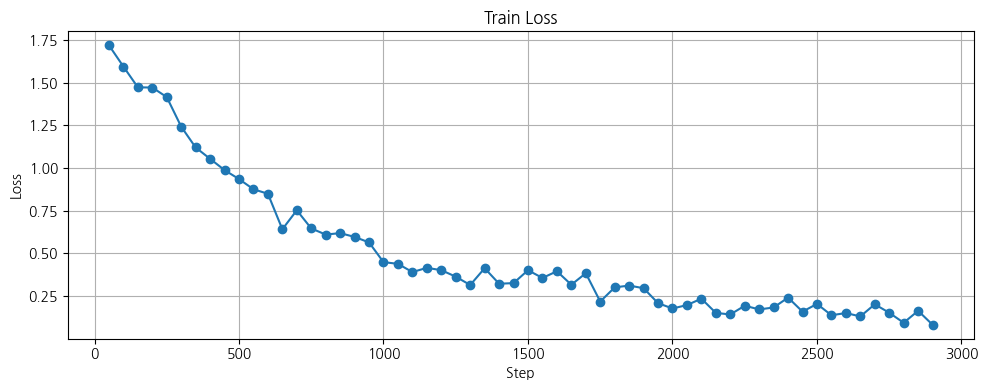

In [ ]:
# =========================
# 8-7. train loss 시각화
# =========================
# 목적:
# - 학습 step이 진행되면서 train loss가 감소하는지 확인한다.
# - loss가 전혀 줄지 않으면 learning rate, 데이터, 라벨 매핑을 의심해야 한다.

import matplotlib.pyplot as plt

# =========================
# 1. train loss 로그만 추출
# =========================

train_loss_df = log_df[
    log_df["loss"].notna()
][["step", "loss"]].copy()

display(train_loss_df.head())

# =========================
# 2. train loss line chart
# =========================

plt.figure(figsize=(10, 4))
plt.plot(train_loss_df["step"], train_loss_df["loss"], marker="o")

plt.title("Train Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

### 8-8. valid loss / accuracy 시각화

,epoch,eval_loss,eval_accuracy
19,1.0,0.512242,0.840361
40,2.0,0.326891,0.903614
60,3.0,0.258019,0.922691
62,3.0,0.258019,0.922691


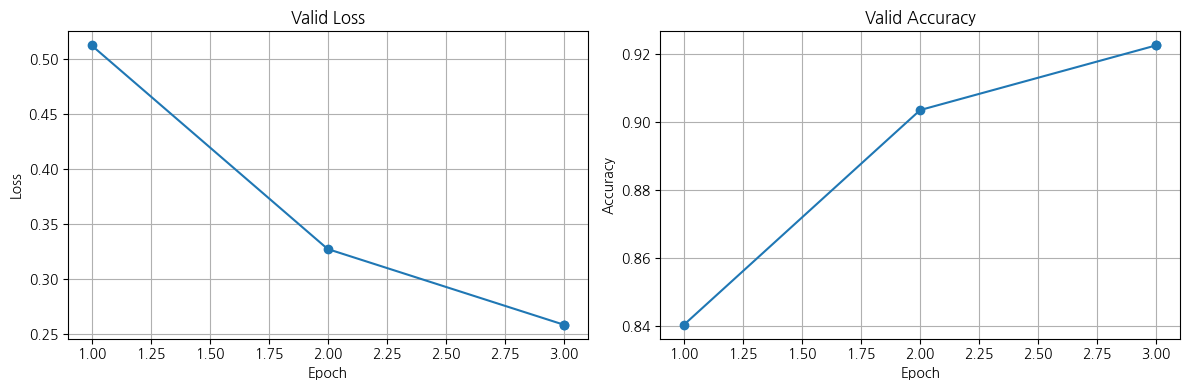

In [ ]:
# =========================
# 8-8. valid loss / accuracy 시각화
# =========================
# 목적:
# - epoch마다 valid loss와 valid accuracy 변화를 확인한다.
# - train loss는 내려가는데 valid 성능이 나빠지면 과적합 가능성이 있다.

import matplotlib.pyplot as plt

# =========================
# 1. eval 로그만 추출
# =========================

eval_df = log_df[
    log_df["eval_loss"].notna()
][["epoch", "eval_loss", "eval_accuracy"]].copy()

display(eval_df)

# =========================
# 2. valid loss와 accuracy를 나란히 시각화
# =========================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(eval_df["epoch"], eval_df["eval_loss"], marker="o")
axes[0].set_title("Valid Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(eval_df["epoch"], eval_df["eval_accuracy"], marker="o")
axes[1].set_title("Valid Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Step 9. 테스트 평가와 예측

### 9-1. test set 평가

In [ ]:
# 모델 확인
print(type(trainer.model))
print(trainer.model.config.id2label)

<class 'transformers.models.vit.modeling_vit.ViTForImageClassification'>
{0: '공통수학1__다항식', 1: '공통수학1__방정식과부등식', 2: '공통수학1__도형의방정식', 3: '공통수학2__집합과명제', 4: '공통수학2__함수', 5: '공통수학2__경우의수'}


In [ ]:
# =========================
# 9. test 평가 준비
# =========================
# 목적:
# - 학습이 끝난 모델을 test_dataset에 적용한다.
# - test loss, test accuracy, classification report, confusion matrix를 확인한다.
# - 오분류 샘플과 top-3 예측 결과를 확인한다.

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from PIL import Image


# =========================
# 1. 라벨 이름 조회 함수
# =========================
# 핵심:
# - id2label key가 int일 수도 있고 string일 수도 있으므로 안전하게 처리한다.
# - 이후 classification report, confusion matrix, top-3 예측 출력에 사용한다.

def get_label_name(label_id):
    if label_id in id2label:
        return id2label[label_id]
    if str(label_id) in id2label:
        return id2label[str(label_id)]
    return str(label_id)


num_labels = len(id2label)
label_names = [get_label_name(i) for i in range(num_labels)]

print("num_labels:", num_labels)
print("label_names:")
for i, name in enumerate(label_names):
    print(i, name)

num_labels: 6
label_names:
0 공통수학1__다항식
1 공통수학1__방정식과부등식
2 공통수학1__도형의방정식
3 공통수학2__집합과명제
4 공통수학2__함수
5 공통수학2__경우의수


In [ ]:
# =========================
# Step 9-1. test set 평가
# =========================
# 목적:
# - trainer.evaluate()로 test loss와 test accuracy를 계산한다.
# - validation이 아니라 최종 hold-out test 성능을 확인하는 단계다.

test_metrics = trainer.evaluate(eval_dataset=test_dataset)

print("test metrics:")
print(test_metrics)

test metrics:
{'eval_loss': 0.19489161670207977, 'eval_accuracy': 0.9376915219611849, 'eval_runtime': 17.872, 'eval_samples_per_second': 54.778, 'eval_steps_per_second': 6.882, 'epoch': 3.0}


- V1
  - test accuracy: 97.04%
  - test loss: 0.1297
- V2 증강
  - test accuracy: 88.46%
  - test loss: 0.3748

- V2-light
  - test accuracy : 93.77%
  - test loss: 0.1948  

### 9-2. confusion matrix 확인

In [ ]:
# =========================
# 9-2. test prediction 생성
# =========================
# 목적:
# - test_dataset 전체에 대해 logits를 얻는다.
# - logits에서 가장 큰 class를 최종 예측 라벨로 변환한다.
# - y_true, y_pred는 이후 report/confusion matrix/top-3 분석에 계속 사용한다.

pred_output = trainer.predict(test_dataset)

logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=1)

test_acc = accuracy_score(y_true, y_pred)

print("logits shape:", logits.shape)
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("test accuracy:", test_acc)

logits shape: (979, 6)
y_true shape: (979,)
y_pred shape: (979,)
test accuracy: 0.9376915219611849


- v1 기본 모델: 97.04%
- v2 강한 증강 모델: 88.46%
- 차이: -8.58%p

### 9-3. top-3 predict 함수

In [ ]:
# =========================
# 9-3. classification report 확인
# =========================
# 목적:
# - 전체 accuracy뿐 아니라 라벨별 precision, recall, f1-score를 확인한다.
# - 특정 단원만 약한지 확인할 때 중요하다.

report_text = classification_report(
    y_true,
    y_pred,
    target_names=label_names,
    digits=4
)

print(report_text)

                precision    recall  f1-score   support

    공통수학1__다항식     0.9264    0.9321    0.9292       162
공통수학1__방정식과부등식     0.9343    0.9299    0.9321       214
 공통수학1__도형의방정식     0.9673    0.9610    0.9642       154
  공통수학2__집합과명제     0.9429    0.9483    0.9456       174
     공통수학2__함수     0.9600    0.9333    0.9465       180
   공통수학2__경우의수     0.8700    0.9158    0.8923        95

      accuracy                         0.9377       979
     macro avg     0.9335    0.9367    0.9350       979
  weighted avg     0.9382    0.9377    0.9378       979



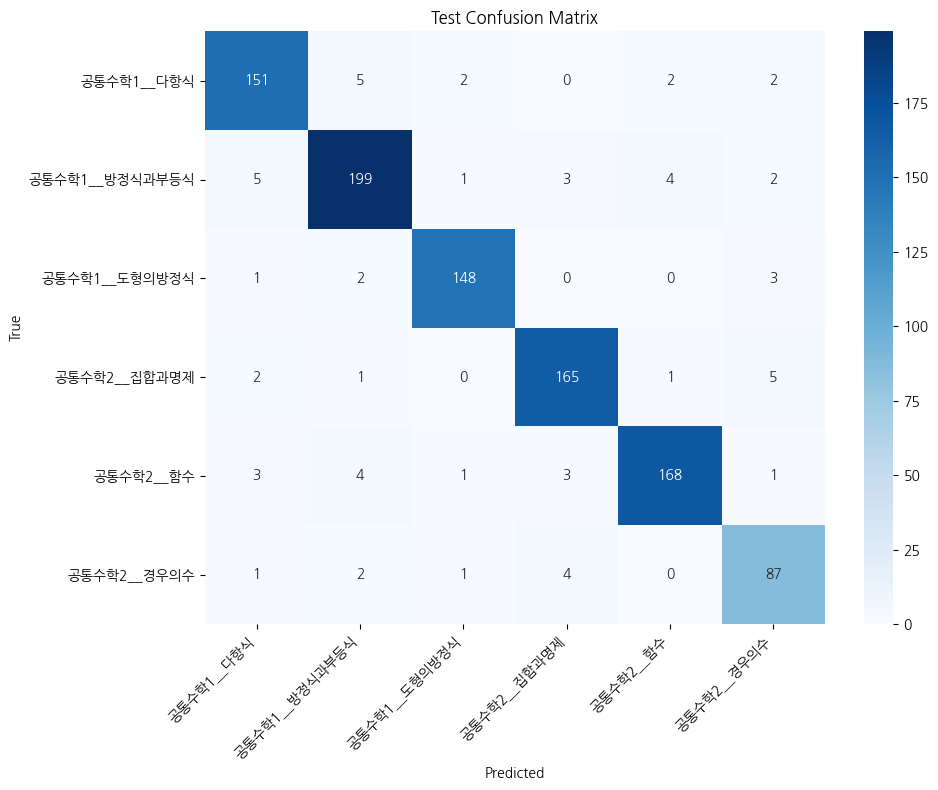

In [ ]:
# =========================
# 9-4. confusion matrix 확인
# =========================
# 목적:
# - 실제 라벨과 예측 라벨이 어떻게 섞였는지 확인한다.
# - 어떤 단원끼리 많이 헷갈리는지 한눈에 볼 수 있다.

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 9-5. test 결과 DataFrame 생성
# =========================
# 목적:
# - test_df에 실제 라벨, 예측 라벨, 정답 여부를 붙인다.
# - 오분류 샘플을 표로 확인할 수 있게 만든다.

test_result_df = test_df.copy().reset_index(drop=True)

test_result_df["true_label_id"] = y_true
test_result_df["pred_label_id"] = y_pred
test_result_df["true_label_name"] = test_result_df["true_label_id"].apply(get_label_name)
test_result_df["pred_label_name"] = test_result_df["pred_label_id"].apply(get_label_name)
test_result_df["correct"] = test_result_df["true_label_id"] == test_result_df["pred_label_id"]

wrong_df = test_result_df[test_result_df["correct"] == False].copy()

print("test rows:", len(test_result_df))
print("wrong rows:", len(wrong_df))
print("accuracy:", test_result_df["correct"].mean())

display(test_result_df.head())
display(wrong_df.head(20))

test rows: 979
wrong rows: 61
accuracy: 0.9376915219611849


,source,sample_id,label_json_path,question_filename,image_zip_path,image_inner_path,term,unit,question_text,question_text_norm,label,label_id,image_found,true_label_id,pred_label_id,true_label_name,pred_label_name,correct
0,110_train,25768_84198,/H_1_01_25768_84198.json,H_1_01_25768_84198.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25768_84198.png,1,01,"세 다항식 $A=-x^3+2x^2-x$, $B=3x^3+4x+2$, $C=-x^2+...","세 다항식 $A=-x^3+2x^2-x$, $B=3x^3+4x+2$, $C=-x^2+...",공통수학1__다항식,0,True,0,0,공통수학1__다항식,공통수학1__다항식,True
1,110_train,25768_84197,/H_1_01_25768_84197.json,H_1_01_25768_84197.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25768_84197.png,1,01,"두 다항식 $A=-x^2+2xy-y^2-4$, $B=5x^2-3xy+y^2+6$에 ...","두 다항식 $A=-x^2+2xy-y^2-4$, $B=5x^2-3xy+y^2+6$에 ...",공통수학1__다항식,0,True,0,0,공통수학1__다항식,공통수학1__다항식,True
2,110_train,25775_84237,/H_1_01_25775_84237.json,H_1_01_25775_84237.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25775_84237.png,1,01,"두 다항식 $X$, $Y$에 대하여 $X ◇ Y$$=X-Y$, $X △ Y$...","두 다항식 $X$, $Y$에 대하여 $X ◇ Y$$=X-Y$, $X △ Y$$=X+...",공통수학1__다항식,0,True,0,0,공통수학1__다항식,공통수학1__다항식,True
3,110_train,25790_84310,/H_1_01_25790_84310.json,H_1_01_25790_84310.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25790_84310.png,1,01,"두 다항식 $A$, $B$에 대하여 $A-B=-9x^2+2xy+10y^2$, $2A...","두 다항식 $A$, $B$에 대하여 $A-B=-9x^2+2xy+10y^2$, $2A...",공통수학1__다항식,0,True,0,0,공통수학1__다항식,공통수학1__다항식,True
4,110_train,25790_84311,/H_1_01_25790_84311.json,H_1_01_25790_84311.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25790_84311.png,1,01,"두 다항식 $A$, $B$에 대하여 $A-B=4x^2+2xy+5y^2$, $2A-B...","두 다항식 $A$, $B$에 대하여 $A-B=4x^2+2xy+5y^2$, $2A-B...",공통수학1__다항식,0,True,0,0,공통수학1__다항식,공통수학1__다항식,True


,source,sample_id,label_json_path,question_filename,image_zip_path,image_inner_path,term,unit,question_text,question_text_norm,label,label_id,image_found,true_label_id,pred_label_id,true_label_name,pred_label_name,correct
9,110_train,25965_84838,/H_1_01_25965_84838.json,H_1_01_25965_84838.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_25965_84838.png,1,01,$101\times(10000-100+1)-99\times(10000+100+1)$...,$101\times(10000-100+1)-99\times(10000+100+1)$...,공통수학1__다항식,0,True,0,1,공통수학1__다항식,공통수학1__방정식과부등식,False
24,110_train,26064_84872,/H_1_02_26064_84872.json,H_1_02_26064_84872.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_02_26064_84872.png,1,02,$x$에 대한 이차방정식 $x^2-2(k-1)x+km-n+3=0$이 실수 $k$의 ...,$x$에 대한 이차방정식 $x^2-2(k-1)x+km-n+3=0$이 실수 $k$의 ...,공통수학1__다항식,0,True,0,1,공통수학1__다항식,공통수학1__방정식과부등식,False
26,110_train,26062_84862,/H_1_02_26062_84862.json,H_1_02_26062_84862.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_02_26062_84862.png,1,02,"$x$, $y$의 값에 관계없이 $\frac{ax-by+1}{3x-2y+5}$의 값...","$x$, $y$의 값에 관계없이 $\frac{ax-by+1}{3x-2y+5}$의 값...",공통수학1__다항식,0,True,0,4,공통수학1__다항식,공통수학2__함수,False
27,110_train,37912_150427,/H_1_01_37912_150427.json,H_1_01_37912_150427.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_01_37912_150427.png,1,01,"크기가 다른 두 공의 반지름의 길이의 합은 $6$이고, 겉넓이의 합은 $56\pi$...","크기가 다른 두 공의 반지름의 길이의 합은 $6$이고, 겉넓이의 합은 $56\pi$...",공통수학1__다항식,0,True,0,5,공통수학1__다항식,공통수학2__경우의수,False
40,110_train,26258_86553,/H_1_02_26258_86553.json,H_1_02_26258_86553.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_02_26258_86553.png,1,02,$86^{95}$을 $85$로 나누었을 때의 나머지를 구하여라.,$86^{95}$을 $85$로 나누었을 때의 나머지를 구하여라.,공통수학1__다항식,0,True,0,5,공통수학1__다항식,공통수학2__경우의수,False
55,110_train,26583_87550,/H_1_02_26583_87550.json,H_1_02_26583_87550.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_02_26583_87550.png,1,02,"$12^4-1$이 두 자리 자연수 $n$으로 나누어떨어진다고 할 때, $n$은 모두...","$12^4-1$이 두 자리 자연수 $n$으로 나누어떨어진다고 할 때, $n$은 모두...",공통수학1__다항식,0,True,0,1,공통수학1__다항식,공통수학1__방정식과부등식,False
62,110_train,26287_87423,/H_1_03_26287_87423.json,H_1_03_26287_87423.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_03_26287_87423.png,1,03,등식 $x(2+2i)+y(4-3i)=\overline{2-9i}$를 만족시키는 실수...,등식 $x(2+2i)+y(4-3i)=\overline{2-9i}$를 만족시키는 실수...,공통수학1__방정식과부등식,1,True,1,0,공통수학1__방정식과부등식,공통수학1__다항식,False
81,110_train,37921_150468,/H_1_03_37921_150468.json,H_1_03_37921_150468.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_03_37921_150468.png,1,03,"$(2+5i)(4-2i)+\frac{1-3i}{3+i}=a+bi$일 때, 실수 $a...","$(2+5i)(4-2i)+\frac{1-3i}{3+i}=a+bi$일 때, 실수 $a...",공통수학1__방정식과부등식,1,True,1,4,공통수학1__방정식과부등식,공통수학2__함수,False
105,110_train,26955_90188,/H_1_06_26955_90188.json,H_1_06_26955_90188.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_06_26955_90188.png,1,06,"어떤 정수의 $3$ 배는 $9$보다 작거나 같고, 그 어떤 정수에 $4$를 더한 것...","어떤 정수의 $3$ 배는 $9$보다 작거나 같고, 그 어떤 정수에 $4$를 더한 것...",공통수학1__방정식과부등식,1,True,1,5,공통수학1__방정식과부등식,공통수학2__경우의수,False
107,110_train,27199_91689,/H_1_06_27199_91689.json,H_1_06_27199_91689.png,/content/110.수학 과목 자동 풀이 데이터/3.개방데이터/1.데이터/Tra...,/H_1_06_27199_91689.png,1,06,"이차부등식 $-x^2+ax-b<0$의 해가 $x$$\ne$$2$인 모든 실수일 때,...","이차부등식 $-x^2+ax-b<0$의 해가 $x$$\ne$$2$인 모든 실수일 때,...",공통수학1__방정식과부등식,1,True,1,0,공통수학1__방정식과부등식,공통수학1__다항식,False


- Test set 979개 중 950개 정답, 29개 오답으로 정확도 97.04%

In [ ]:
# =========================
# 9-6. top-3 predict 결과 생성
# =========================
# 목적:
# - 정답 라벨이 top-1은 아니더라도 top-3 안에 들어오는지 확인한다.
# - 헷갈린 문제에서 모델이 어떤 후보를 높게 봤는지 분석할 수 있다.

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
top3_ids = np.argsort(-probs, axis=1)[:, :3]

for rank in range(3):
    test_result_df[f"top{rank+1}_label_id"] = top3_ids[:, rank]
    test_result_df[f"top{rank+1}_label_name"] = [
        get_label_name(label_id) for label_id in top3_ids[:, rank]
    ]
    test_result_df[f"top{rank+1}_prob"] = probs[
        np.arange(len(probs)),
        top3_ids[:, rank]
    ]

test_result_df["true_in_top3"] = [
    y_true[i] in top3_ids[i] for i in range(len(y_true))
]

print("top-1 accuracy:", test_result_df["correct"].mean())
print("top-3 accuracy:", test_result_df["true_in_top3"].mean())

display(test_result_df[
    [
        "true_label_name",
        "pred_label_name",
        "correct",
        "true_in_top3",
        "top1_label_name",
        "top1_prob",
        "top2_label_name",
        "top2_prob",
        "top3_label_name",
        "top3_prob",
    ]
].head(20))

top-1 accuracy: 0.9376915219611849
top-3 accuracy: 0.9918283963227783


,true_label_name,pred_label_name,correct,true_in_top3,top1_label_name,top1_prob,top2_label_name,top2_prob,top3_label_name,top3_prob
0,공통수학1__다항식,공통수학1__다항식,True,True,공통수학1__다항식,0.996406,공통수학1__방정식과부등식,0.001666,공통수학2__집합과명제,0.000894
1,공통수학1__다항식,공통수학1__다항식,True,True,공통수학1__다항식,0.998450,공통수학1__방정식과부등식,0.000670,공통수학2__집합과명제,0.000301
2,공통수학1__다항식,공통수학1__다항식,True,True,공통수학1__다항식,0.998756,공통수학1__방정식과부등식,0.000423,공통수학2__경우의수,0.000262
3,공통수학1__다항식,공통수학1__다항식,True,True,공통수학1__다항식,0.997346,공통수학1__도형의방정식,0.001139,공통수학1__방정식과부등식,0.000652
4,공통수학1__다항식,공통수학1__다항식,True,True,공통수학1__다항식,0.996509,공통수학2__집합과명제,0.001062,공통수학1__방정식과부등식,0.001052
5,공통수학1__다항식,공통수학1__다항식,True,True,공통수학1__다항식,0.999172,공통수학1__방정식과부등식,0.000365,공통수학2__경우의수,0.000154
6,공통수학1__다항식,공통수학1__다항식,True,True,공통수학1__다항식,0.998610,공통수학1__방정식과부등식,0.000451,공통수학2__경우의수,0.000325
7,공통수학1__다항식,공통수학1__다항식,True,True,공통수학1__다항식,0.997733,공통수학1__방정식과부등식,0.001661,공통수학2__함수,0.000301
8,공통수학1__다항식,공통수학1__다항식,True,True,공통수학1__다항식,0.973933,공통수학1__방정식과부등식,0.020957,공통수학2__함수,0.002795
9,공통수학1__다항식,공통수학1__방정식과부등식,False,True,공통수학1__방정식과부등식,0.600148,공통수학1__다항식,0.375563,공통수학2__집합과명제,0.008411


- 1순위 정답은 많이 틀림, 하지만 정답이 3순위 안에는 거의 들어옴
```
V1 top-3 accuracy가 97.45%
V2
  top-1 accuracy: 88.46%
  top-3 accuracy: 97.45%
V2 - light
  top-1 accuracy: 0.9376915219611849
  top-3 accuracy: 0.9918283963227783  
```

### 9-4. 오분류 이미지 확인

In [ ]:
# =========================
# 9-7. 오분류 이미지 확인
# =========================
# 목적:
# - test set에서 모델이 틀린 이미지(wrong_df)를 실제로 열어본다.
# - confusion matrix와 classification report는 숫자 분석이고,
#   이 단계는 오분류 원인을 사람이 직접 눈으로 확인하는 단계다.
#
# 확인할 수 있는 것:
# - 모델이 실제로 단원 경계를 헷갈렸는지
# - 문제 이미지나 라벨 자체가 애매한지
# - 라벨 오류 또는 이미지 품질 문제가 있는지
#
# 현재 데이터 구조:
# - 이미지는 일반 폴더 경로가 아니라 zip 파일 내부에 들어 있다.
# - 따라서 image_zip_path + image_inner_path를 이용해 zip 내부 이미지를 읽어야 한다.

import zipfile
from io import BytesIO
from pathlib import PurePosixPath

from PIL import Image
import matplotlib.pyplot as plt

# =========================
# 1. zip 내부 경로 정규화 함수
# =========================
# 핵심:
# - DataFrame의 image_inner_path에는 앞에 "/"가 붙어 있을 수 있다.
# - Windows/POSIX slash 차이도 있을 수 있으므로 "/" 기준으로 통일한다.
# - 이 함수는 비교용 경로를 만드는 함수다.
# - 실제 zf.open()에는 zip에 저장된 원본 entry name을 사용하는 것이 안전하다.

def normalize_zip_name(name):
    return str(name).replace("\\", "/").lstrip("/")


# =========================
# 2. zip 내부 entry index 생성
# =========================
# 목적:
# - zip 파일 안의 이미지 목록을 한 번만 읽고 캐시에 저장한다.
# - 오분류 이미지를 여러 장 볼 때 매번 zip 목록을 다시 읽지 않게 한다.
#
# 저장하는 값:
# - raw_names: zip 안에 실제 저장된 원본 entry name 목록
# - norm_to_raw: 정규화된 경로 -> 원본 entry name 매핑
# - filename_to_raw: 파일명만 -> 원본 entry name 목록 매핑

zip_entry_cache = {}

def get_zip_entry_index(zip_path):
    zip_path = str(zip_path)

    if zip_path not in zip_entry_cache:
        with zipfile.ZipFile(zip_path, "r") as zf:
            raw_names = [
                info.filename
                for info in zf.infolist()
                if not info.is_dir()
            ]

        norm_to_raw = {}
        filename_to_raw = {}

        for raw_name in raw_names:
            norm_name = normalize_zip_name(raw_name)
            filename = PurePosixPath(norm_name).name

            norm_to_raw[norm_name] = raw_name
            filename_to_raw.setdefault(filename, []).append(raw_name)

        zip_entry_cache[zip_path] = {
            "raw_names": raw_names,
            "norm_to_raw": norm_to_raw,
            "filename_to_raw": filename_to_raw,
        }

    return zip_entry_cache[zip_path]



# =========================
# 3. row에서 실제 zip 내부 이미지 entry 찾기
# =========================
# 목적:
# - test_result_df 또는 wrong_df의 row 하나를 받아 실제 zip 내부 이미지 경로를 찾는다.
#
# 찾는 순서:
# 1) image_inner_path를 정규화한 전체 경로로 찾는다.
# 2) 실패하면 파일명만 비교해서 찾는다.
#
# 주의:
# - zf.open()에는 정규화된 경로가 아니라 raw_entry를 넣는다.
# - raw_entry는 zip 파일 안에 실제 저장된 원본 이름이다.

def resolve_image_raw_entry(row):
    zip_path = row["image_zip_path"]
    raw_inner_path = row["image_inner_path"]

    norm_inner_path = normalize_zip_name(raw_inner_path)
    target_filename = PurePosixPath(norm_inner_path).name

    index = get_zip_entry_index(zip_path)

    # 1순위: 정규화된 전체 경로가 zip 내부 목록과 일치하는 경우
    if norm_inner_path in index["norm_to_raw"]:
        return index["norm_to_raw"][norm_inner_path]

    # 2순위: 파일명만 일치하는 경우
    matches = index["filename_to_raw"].get(target_filename, [])

    if len(matches) == 1:
        return matches[0]

    if len(matches) > 1:
        raise ValueError(
            f"같은 파일명이 zip 안에 여러 개 있습니다: {target_filename}\n"
            f"matches={matches[:20]}"
        )

    raise FileNotFoundError(
        f"zip 안에서 이미지를 찾지 못했습니다.\n"
        f"zip_path={zip_path}\n"
        f"image_inner_path={raw_inner_path}\n"
        f"norm_inner_path={norm_inner_path}\n"
        f"target_filename={target_filename}\n"
        f"raw sample names={index['raw_names'][:20]}"
    )


# =========================
# 4. zip 내부 이미지 로드 함수
# =========================
# 목적:
# - row 하나를 받아 zip 내부 이미지를 PIL Image로 읽어온다.
#
# 핵심:
# - resolve_image_raw_entry(row)로 실제 zip entry를 찾는다.
# - zf.open(raw_entry)로 zip 내부 이미지를 bytes로 읽는다.
# - PIL Image로 변환해서 matplotlib에서 볼 수 있게 한다.

def load_image_from_zip_row(row):
    zip_path = row["image_zip_path"]
    raw_entry = resolve_image_raw_entry(row)

    with zipfile.ZipFile(zip_path, "r") as zf:
        with zf.open(raw_entry) as f:
            image_bytes = f.read()

    image = Image.open(BytesIO(image_bytes)).convert("RGB")

    return image

row image_inner_path: /H_1_01_25965_84838.png
resolved raw_entry: '/H_1_01_25965_84838.png'


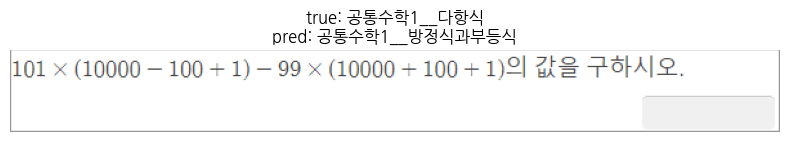

In [ ]:
# =========================
# 5. 오분류 이미지 1장 로드 테스트
# =========================
# 목적:
# - 전체 이미지를 보기 전에 wrong_df 첫 번째 이미지가 정상적으로 열리는지 확인한다.
# - raw_entry가 어떤 zip 내부 경로로 해석되는지도 함께 출력한다.

debug_row = wrong_df.iloc[0]

raw_entry = resolve_image_raw_entry(debug_row)

print("row image_inner_path:", debug_row["image_inner_path"])
print("resolved raw_entry:", repr(raw_entry))

img = load_image_from_zip_row(debug_row)

plt.figure(figsize=(8, 4))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"true: {debug_row['true_label_name']}\n"
    f"pred: {debug_row['pred_label_name']}"
)
plt.tight_layout()
plt.show()

wrong rows: 61
sample wrong rows: 12


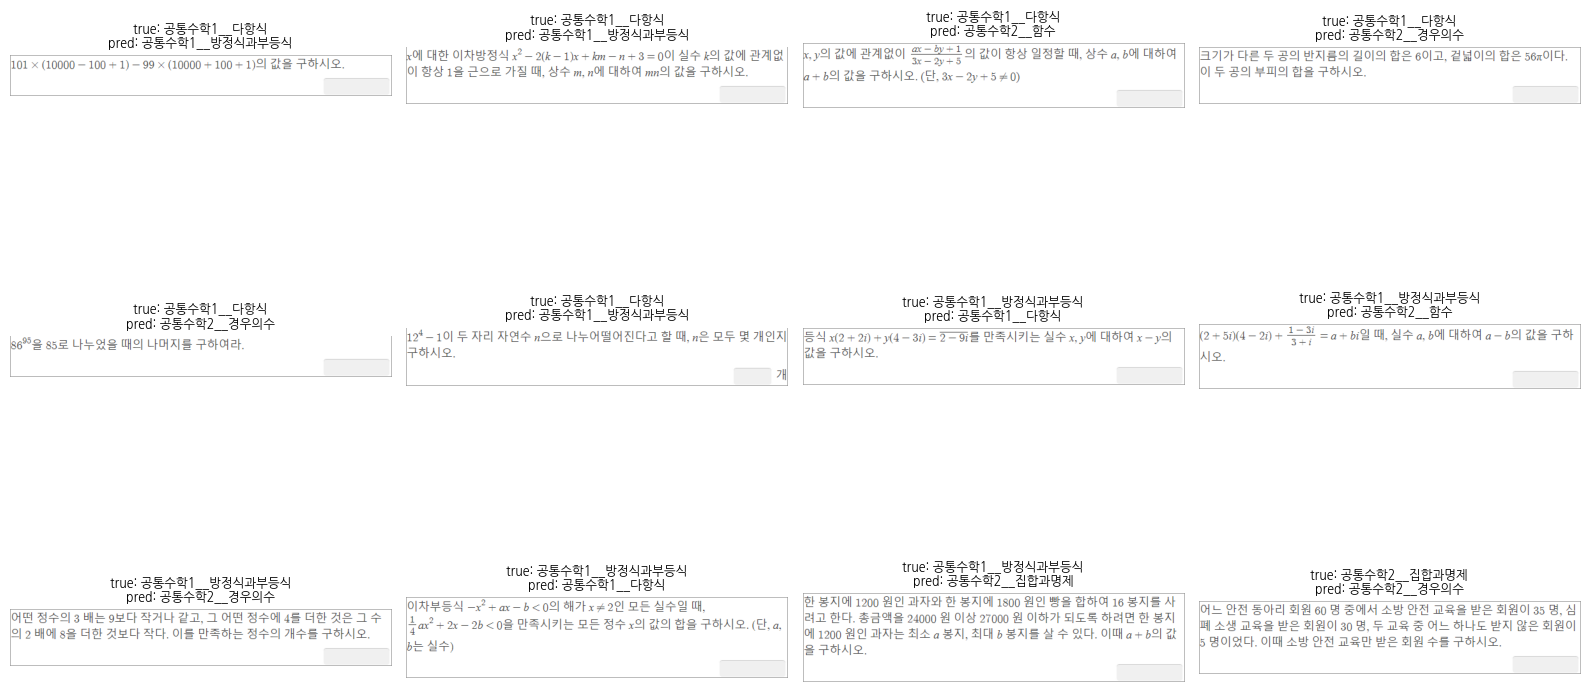

In [ ]:
# =========================
# 6. 오분류 이미지 샘플 여러 장 출력
# =========================
# 목적:
# - wrong_df에서 앞 12개 오분류 이미지를 확인한다.
# - 각 이미지마다 실제 라벨 true와 예측 라벨 pred를 제목으로 표시한다.
#
# 해석:
# - 사람이 봐도 애매하면 라벨 기준이나 데이터 자체를 점검한다.
# - 사람이 보면 명확한데 모델이 틀렸다면 해당 조합의 데이터를 보강할 수 있다.

sample_wrong_df = wrong_df.head(12).reset_index(drop=True)

print("wrong rows:", len(wrong_df))
print("sample wrong rows:", len(sample_wrong_df))

plt.figure(figsize=(16, 10))

for i, row in sample_wrong_df.iterrows():
    img = load_image_from_zip_row(row)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"true: {row['true_label_name']}\n"
        f"pred: {row['pred_label_name']}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### 9-5. 실제 이미지 예측 테스트

- 추론전 Crop+Padding 추가
  - 원본 이미지와 비슷하게 이미지 변경 후 추론

In [ ]:
# =========================
# 9-5-1. 추론 전 자동 crop + padding 함수
# =========================
# 목적:
# - 실제 촬영 사진에서 글자/수식이 있는 영역을 자동으로 찾는다.
# - 넓은 여백을 줄이고, 문제 본문 비중을 키운다.
# - crop 영역 주변에는 padding을 붙여서 글자가 잘리지 않게 한다.
#
# 주의:
# - 이 코드는 "문제 하나를 완벽히 분리"하는 모델은 아니다.
# - 우선 원본 사진 그대로 넣는 것보다 crop 후 예측이 안정되는지 확인하기 위한 MVP 전처리다.

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files


# =========================
# 1. 기본 추론 상태 확인
# =========================
# 핵심:
# - checkpoint-2925를 로드한 model이 있어야 한다.
# - trainer.model만 있는 경우 model 변수로 연결한다.

if "model" not in globals() and "trainer" in globals():
    model = trainer.model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

print("device:", device)

# =========================
# 2. 라벨 이름 조회 함수
# =========================
# 핵심:
# - id2label key가 int일 수도 있고 string일 수도 있으므로 안전하게 처리한다.

def get_label_name(label_id):
    label_id = int(label_id)

    if label_id in id2label:
        return id2label[label_id]

    if str(label_id) in id2label:
        return id2label[str(label_id)]

    return str(label_id)

# =========================
# 3. 자동 crop 함수
# =========================
# 목적:
# - 이미지에서 어두운 글자/수식/필기 영역을 찾는다.
# - 해당 영역 전체를 감싸는 bounding box를 만든다.
# - padding_ratio만큼 주변 여백을 추가한다.

def auto_crop_text_region(
    image,
    padding_ratio=0.10,
    min_area_ratio=0.0005,
):
    image = image.convert("RGB")

    cv_img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    height, width = cv_img.shape[:2]

    gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 어두운 글자/수식/필기 영역을 흰색 foreground로 추출
    binary = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        31,
        12,
    )

    # 작은 글자 조각을 조금 연결해서 문항 영역을 잡기 쉽게 만든다.
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3))
    binary = cv2.dilate(binary, kernel, iterations=1)

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    boxes = []
    image_area = width * height
    min_area = image_area * min_area_ratio

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = w * h

        if area < min_area:
            continue

        boxes.append((x, y, x + w, y + h))

    # 글자 영역을 못 찾으면 원본을 그대로 사용한다.
    if len(boxes) == 0:
        return image, {
            "used_crop": False,
            "reason": "no_text_region_found",
            "box": (0, 0, width, height),
            "original_size": (width, height),
            "crop_size": (width, height),
        }

    x1 = min(box[0] for box in boxes)
    y1 = min(box[1] for box in boxes)
    x2 = max(box[2] for box in boxes)
    y2 = max(box[3] for box in boxes)

    box_w = x2 - x1
    box_h = y2 - y1

    pad_x = int(box_w * padding_ratio)
    pad_y = int(box_h * padding_ratio)

    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(width, x2 + pad_x)
    y2 = min(height, y2 + pad_y)

    cropped = image.crop((x1, y1, x2, y2))

    return cropped, {
        "used_crop": True,
        "reason": "ok",
        "box": (x1, y1, x2, y2),
        "original_size": (width, height),
        "crop_size": cropped.size,
    }


# =========================
# 4. crop 옵션이 있는 예측 함수
# =========================
# 목적:
# - use_crop=False이면 원본 그대로 예측한다.
# - use_crop=True이면 자동 crop + padding 후 예측한다.
# - 같은 이미지에서 원본 예측과 crop 예측을 비교할 수 있다.
# =========================
# predict_image 재정의 - crop + square padding 지원
# =========================

def predict_image(
    image_path,
    top_k=3,
    use_crop=False,
    use_square_pad=False,
):
    original_image = Image.open(image_path).convert("RGB")

    if use_crop:
        input_image, crop_info = auto_crop_text_region(original_image)
    else:
        input_image = original_image
        crop_info = {
            "used_crop": False,
            "reason": "disabled",
            "box": (0, 0, original_image.width, original_image.height),
            "original_size": original_image.size,
            "crop_size": original_image.size,
        }

    if use_square_pad:
        input_image = pad_to_square(input_image)
        crop_info["used_square_pad"] = True
        crop_info["padded_size"] = input_image.size
    else:
        crop_info["used_square_pad"] = False
        crop_info["padded_size"] = input_image.size

    inputs = processor(
        images=input_image,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0].cpu().numpy()

    top_ids = np.argsort(-probs)[:top_k]

    results = []
    for rank, label_id in enumerate(top_ids, start=1):
        results.append({
            "rank": rank,
            "label_id": int(label_id),
            "label_name": get_label_name(label_id),
            "prob": float(probs[label_id]),
        })

    return original_image, input_image, results, crop_info


# def predict_image(image_path, top_k=3, use_crop=False):
#     original_image = Image.open(image_path).convert("RGB")

#     if use_crop:
#         input_image, crop_info = auto_crop_text_region(original_image)
#     else:
#         input_image = original_image
#         crop_info = {
#             "used_crop": False,
#             "reason": "disabled",
#             "box": (0, 0, original_image.width, original_image.height),
#             "original_size": original_image.size,
#             "crop_size": original_image.size,
#         }

#     inputs = processor(
#         images=input_image,
#         return_tensors="pt"
#     )

#     inputs = {
#         key: value.to(device)
#         for key, value in inputs.items()
#     }

#     with torch.inference_mode():
#         outputs = model(**inputs)
#         probs = torch.softmax(outputs.logits, dim=-1)[0].cpu().numpy()

#     top_ids = np.argsort(-probs)[:top_k]

#     results = []
#     for rank, label_id in enumerate(top_ids, start=1):
#         results.append({
#             "rank": rank,
#             "label_id": int(label_id),
#             "label_name": get_label_name(label_id),
#             "prob": float(probs[label_id]),
#         })

#     return original_image, input_image, results, crop_info


# =========================
# 5. 원본 vs crop 이미지 비교 출력 함수
# =========================
# 목적:
# - 자동 crop이 문제 영역을 잘 잡았는지 눈으로 확인한다.

def show_original_and_crop(original_image, cropped_image, crop_info):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(original_image)
    axes[0].axis("off")
    axes[0].set_title("Original")

    axes[1].imshow(cropped_image)
    axes[1].axis("off")
    axes[1].set_title(
        f"Cropped | used={crop_info['used_crop']} | size={crop_info['crop_size']}"
    )

    plt.tight_layout()
    plt.show()


#==========================================================================================

# =========================
# 3-1. 정사각형 white padding 함수
# =========================
# 목적:
# - 가로로 긴 문제 이미지를 바로 384x384로 찌그러뜨리지 않는다.
# - 긴 변에 맞춘 정사각형 흰 캔버스를 만들고, 원본 crop 이미지를 중앙에 붙인다.
# - 학습 이미지처럼 문제 비율을 최대한 보존한 상태로 모델에 넣기 위한 전처리다.

def pad_to_square(image, fill_color=(255, 255, 255)):
    image = image.convert("RGB")

    width, height = image.size
    square_size = max(width, height)

    padded = Image.new("RGB", (square_size, square_size), fill_color)

    paste_x = (square_size - width) // 2
    paste_y = (square_size - height) // 2

    padded.paste(image, (paste_x, paste_y))

    return padded


device: cuda


### 9-5-2 실제 이미지 예측 테스트

In [ ]:
prediction_history = []
print("prediction_history initialized")

prediction_history initialized


In [ ]:
# =========================
# 9-5. 실제 이미지 1장 업로드 예측 테스트
# =========================
# 목적:
# - 내가 직접 올린 문제 이미지 1장을 학습된 모델에 넣어본다.
# - 모델이 예측한 top-1 단원과 top-3 후보를 확인한다.
# - 데이터셋 이미지가 아니라 실제 사용 이미지에서도 동작하는지 확인한다.

import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files


# =========================
# 1. 추론용 모델 설정
# =========================
# 핵심:
# - trainer.model은 방금 학습이 끝난 최신 모델이다.
# - GPU가 있으면 cuda에서 추론하고, 없으면 cpu에서 추론한다.
# - eval()은 모델을 추론 모드로 바꾸는 설정이다.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

inference_model = trainer.model
inference_model.to(device)
inference_model.eval()

# 결과 history
prediction_history = []

print("device:", device)


# =========================
# 2. 라벨 이름 조회 함수
# =========================
# 핵심:
# - id2label의 key가 int일 수도 있고 string일 수도 있어서 안전하게 처리한다.
# - 예측 결과를 사람이 읽을 수 있는 단원명으로 바꾼다.

def get_label_name(label_id):
    if label_id in id2label:
        return id2label[label_id]
    if str(label_id) in id2label:
        return id2label[str(label_id)]
    return str(label_id)


print("labels:")
for i in range(len(id2label)):
    print(i, get_label_name(i))



device: cuda
labels:
0 공통수학1__다항식
1 공통수학1__방정식과부등식
2 공통수학1__도형의방정식
3 공통수학2__집합과명제
4 공통수학2__함수
5 공통수학2__경우의수


Saving 11.jpg to 11.jpg


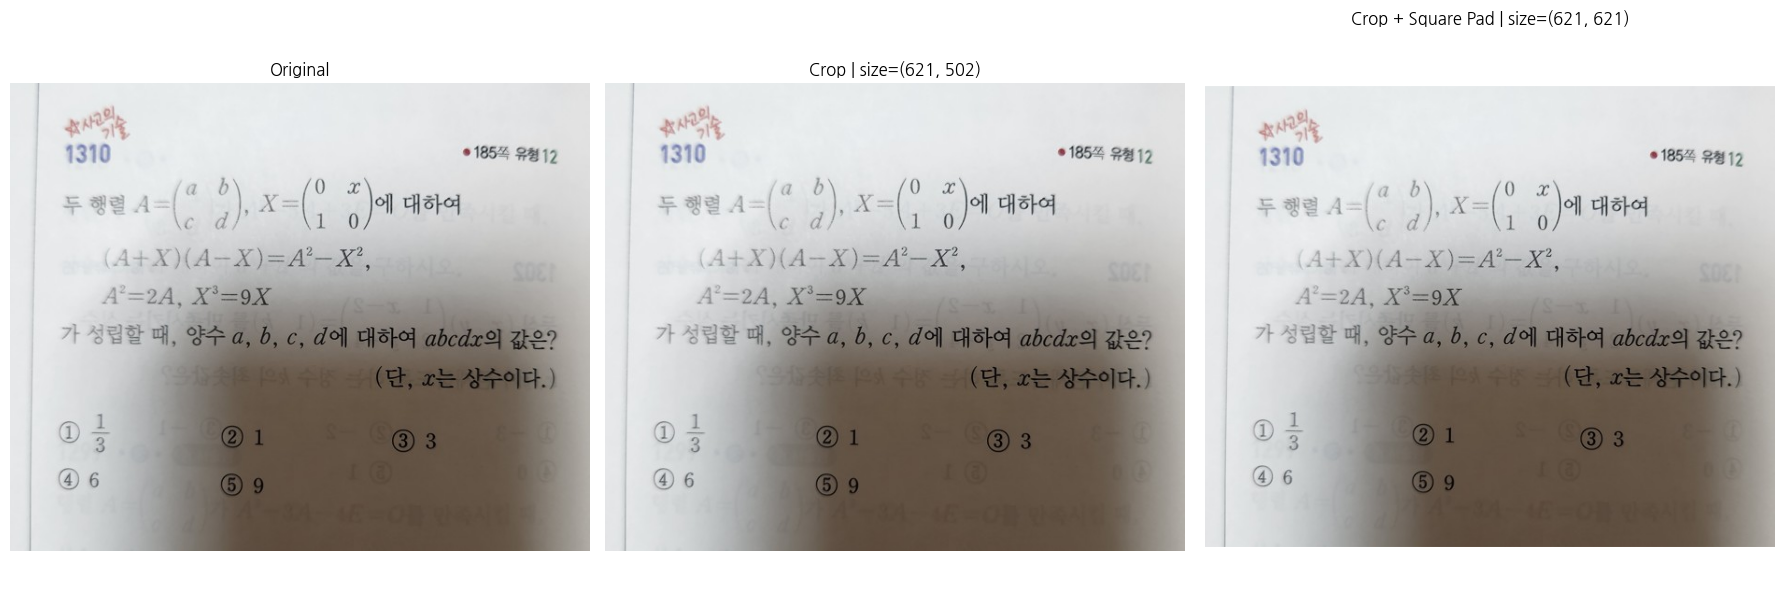

saved predictions: 4
===== original prediction =====
top-1 | 공통수학2__함수 | prob=0.5692
top-2 | 공통수학2__집합과명제 | prob=0.1552
top-3 | 공통수학1__방정식과부등식 | prob=0.1429

===== cropped prediction =====
top-1 | 공통수학2__함수 | prob=0.5692
top-2 | 공통수학2__집합과명제 | prob=0.1552
top-3 | 공통수학1__방정식과부등식 | prob=0.1429

===== cropped + square padded prediction =====
top-1 | 공통수학2__집합과명제 | prob=0.4500
top-2 | 공통수학1__다항식 | prob=0.2835
top-3 | 공통수학2__함수 | prob=0.1154

crop info:
{'used_crop': True, 'reason': 'ok', 'box': (0, 0, 621, 502), 'original_size': (621, 502), 'crop_size': (621, 502), 'used_square_pad': False, 'padded_size': (621, 502)}

padded info:
{'used_crop': True, 'reason': 'ok', 'box': (0, 0, 621, 502), 'original_size': (621, 502), 'crop_size': (621, 502), 'used_square_pad': True, 'padded_size': (621, 621)}


In [ ]:
# # =========================
# # 3. 실제 이미지 업로드
# # =========================
# # 목적:
# # - 내 컴퓨터에 있는 문제 이미지 1장을 Colab에 업로드한다.
# # - jpg, jpeg, png 모두 가능하다.

# uploaded = files.upload()

# image_path = list(uploaded.keys())[0]

# print("uploaded image:", image_path)

# =========================
# 9-5-2. 원본 vs crop vs crop+padding 예측 비교
# =========================
# 목적:
# - 원본 그대로 예측한다.
# - 자동 crop 후 예측한다.
# - 자동 crop + 정사각형 padding 후 예측한다.
# - 어떤 입력 방식이 가장 안정적인지 비교한다.

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

original_image, raw_input_image, raw_results, raw_info = predict_image(
    image_path,
    top_k=3,
    use_crop=False,
    use_square_pad=False,
)

_, crop_input_image, crop_results, crop_info = predict_image(
    image_path,
    top_k=3,
    use_crop=True,
    use_square_pad=False,
)

_, padded_input_image, padded_results, padded_info = predict_image(
    image_path,
    top_k=3,
    use_crop=True,
    use_square_pad=True,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(raw_input_image)
axes[0].axis("off")
axes[0].set_title("Original")

axes[1].imshow(crop_input_image)
axes[1].axis("off")
axes[1].set_title(f"Crop | size={crop_input_image.size}")

axes[2].imshow(padded_input_image)
axes[2].axis("off")
axes[2].set_title(f"Crop + Square Pad | size={padded_input_image.size}")

plt.tight_layout()
plt.show()


def print_results(title, results):
    print(title)
    for item in results:
        print(
            f"top-{item['rank']} | "
            f"{item['label_name']} | "
            f"prob={item['prob']:.4f}"
        )
    print()


prediction_history.append({
    "image_path": image_path,
    "original_results": raw_results,
    "cropped_results": crop_results,
    "padded_results": padded_results,
    "original_image": raw_input_image.copy(),
    "cropped_image": crop_input_image.copy(),
    "padded_image": padded_input_image.copy(),
})

print("saved predictions:", len(prediction_history))


print_results("===== original prediction =====", raw_results)
print_results("===== cropped prediction =====", crop_results)
print_results("===== cropped + square padded prediction =====", padded_results)

print("crop info:")
print(crop_info)

print()
print("padded info:")
print(padded_info)


- crop 문제만은 아님
- 비율/padding으로 약간 완화됐지만, 모델이 이 실제 사진/유형을 여전히 함수 쪽으로 강하게 본다

In [ ]:
# =========================
# 4. crop + square padding 옵션이 있는 예측 함수
# =========================
# 목적:
# - use_crop=False이면 원본 그대로 예측한다.
# - use_crop=True이면 자동 crop을 적용한다.
# - use_square_pad=True이면 crop 후 정사각형 흰 배경 padding을 적용한다.
#
# 추천:
# - 실제 촬영 이미지는 use_crop=True, use_square_pad=True로 비교해본다.

def predict_image(
    image_path,
    top_k=3,
    use_crop=False,
    use_square_pad=False,
):
    original_image = Image.open(image_path).convert("RGB")

    if use_crop:
        input_image, crop_info = auto_crop_text_region(original_image)
    else:
        input_image = original_image
        crop_info = {
            "used_crop": False,
            "reason": "disabled",
            "box": (0, 0, original_image.width, original_image.height),
            "original_size": original_image.size,
            "crop_size": original_image.size,
        }

    if use_square_pad:
        input_image = pad_to_square(input_image)
        crop_info["used_square_pad"] = True
        crop_info["padded_size"] = input_image.size
    else:
        crop_info["used_square_pad"] = False
        crop_info["padded_size"] = input_image.size

    inputs = processor(
        images=input_image,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)[0].cpu().numpy()

    top_ids = np.argsort(-probs)[:top_k]

    results = []
    for rank, label_id in enumerate(top_ids, start=1):
        results.append({
            "rank": rank,
            "label_id": int(label_id),
            "label_name": get_label_name(label_id),
            "prob": float(probs[label_id]),
        })

    return original_image, input_image, results, crop_info

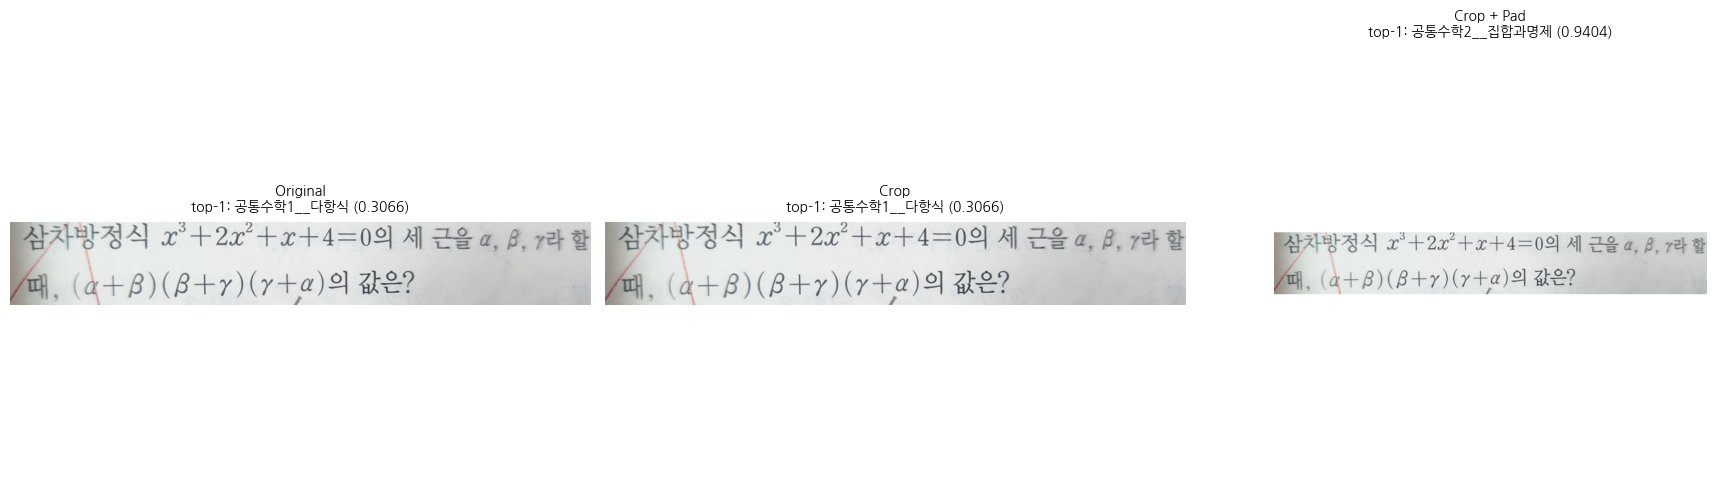

[0] image_path: 22 (2).jpg

Original
top-1 | 공통수학1__다항식 | 0.3066
top-2 | 공통수학2__함수 | 0.2190
top-3 | 공통수학1__방정식과부등식 | 0.1745

Crop
top-1 | 공통수학1__다항식 | 0.3066
top-2 | 공통수학2__함수 | 0.2190
top-3 | 공통수학1__방정식과부등식 | 0.1745

Crop + Pad
top-1 | 공통수학2__집합과명제 | 0.9404
top-2 | 공통수학1__다항식 | 0.0314
top-3 | 공통수학2__함수 | 0.0105


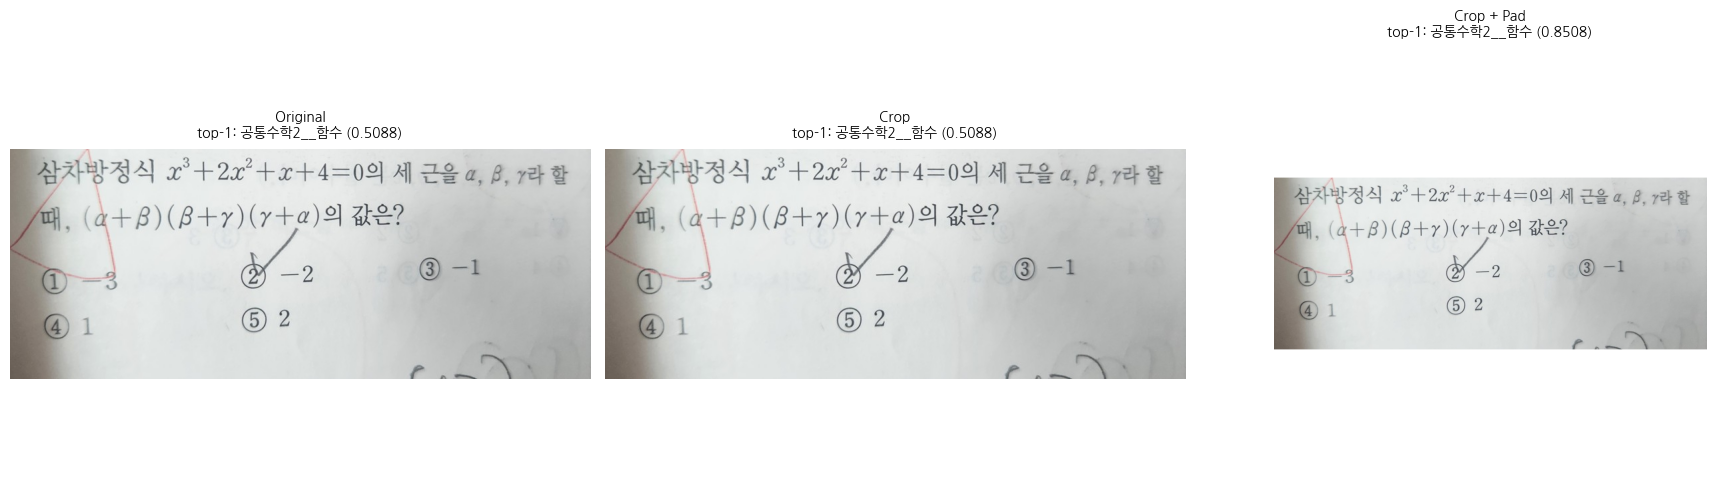

[1] image_path: 23 (1).jpg

Original
top-1 | 공통수학2__함수 | 0.5088
top-2 | 공통수학2__집합과명제 | 0.2606
top-3 | 공통수학1__도형의방정식 | 0.1374

Crop
top-1 | 공통수학2__함수 | 0.5088
top-2 | 공통수학2__집합과명제 | 0.2606
top-3 | 공통수학1__도형의방정식 | 0.1374

Crop + Pad
top-1 | 공통수학2__함수 | 0.8508
top-2 | 공통수학2__집합과명제 | 0.0998
top-3 | 공통수학1__도형의방정식 | 0.0300


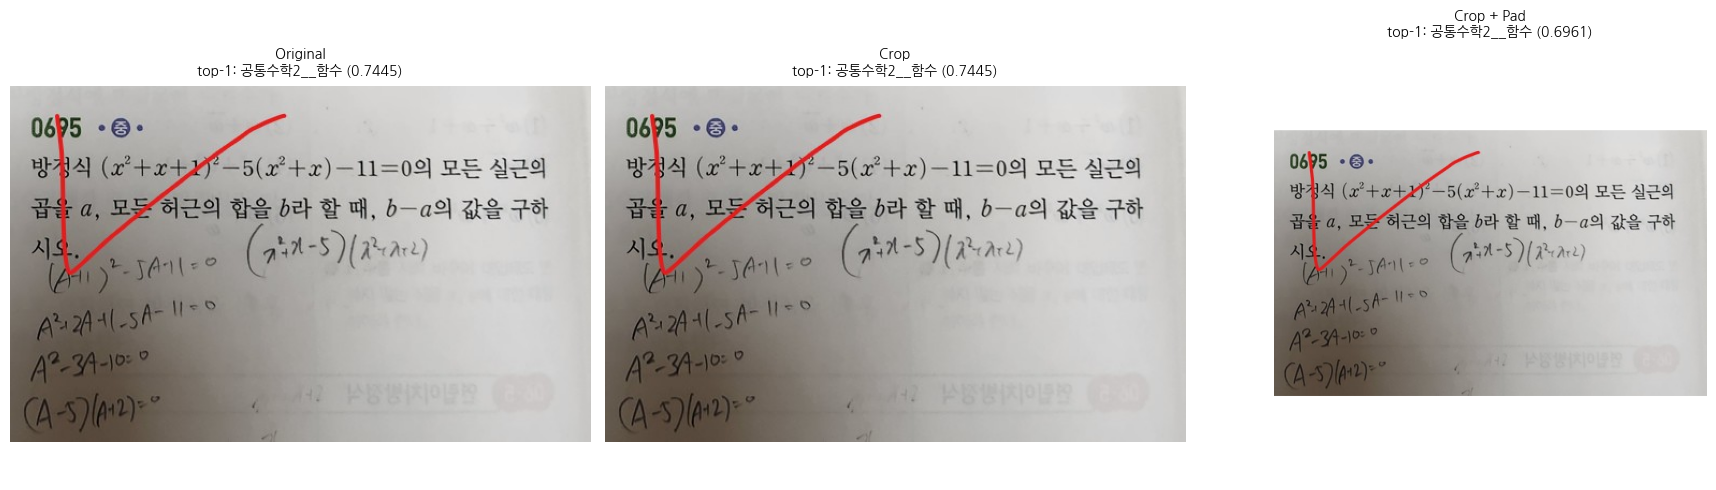

[2] image_path: 1.jpg

Original
top-1 | 공통수학2__함수 | 0.7445
top-2 | 공통수학2__집합과명제 | 0.1002
top-3 | 공통수학1__방정식과부등식 | 0.0732

Crop
top-1 | 공통수학2__함수 | 0.7445
top-2 | 공통수학2__집합과명제 | 0.1002
top-3 | 공통수학1__방정식과부등식 | 0.0732

Crop + Pad
top-1 | 공통수학2__함수 | 0.6961
top-2 | 공통수학2__집합과명제 | 0.1275
top-3 | 공통수학1__다항식 | 0.0997


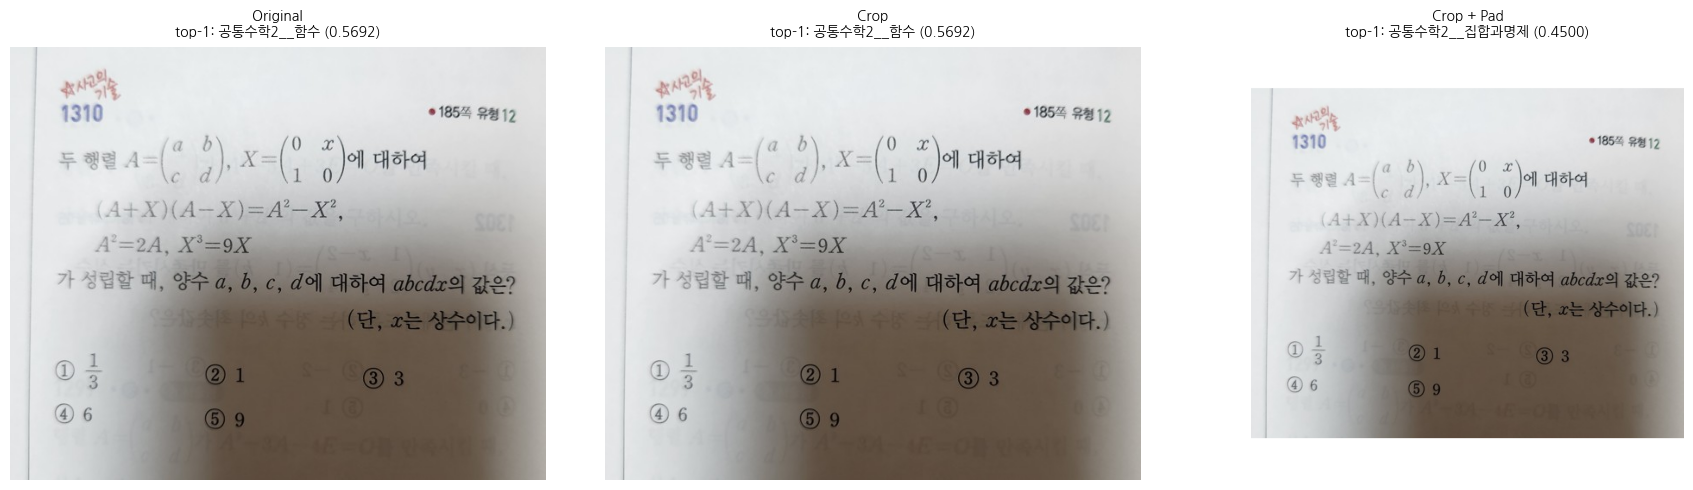

[3] image_path: 11.jpg

Original
top-1 | 공통수학2__함수 | 0.5692
top-2 | 공통수학2__집합과명제 | 0.1552
top-3 | 공통수학1__방정식과부등식 | 0.1429

Crop
top-1 | 공통수학2__함수 | 0.5692
top-2 | 공통수학2__집합과명제 | 0.1552
top-3 | 공통수학1__방정식과부등식 | 0.1429

Crop + Pad
top-1 | 공통수학2__집합과명제 | 0.4500
top-2 | 공통수학1__다항식 | 0.2835
top-3 | 공통수학2__함수 | 0.1154


In [ ]:
# 비교(이미지 포함) - 제목 짧게, top-3는 아래에 텍스트로 출력

for i, item in enumerate(prediction_history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    view_items = [
        ("Original", item["original_image"], item["original_results"]),
        ("Crop", item["cropped_image"], item["cropped_results"]),
        ("Crop + Pad", item["padded_image"], item["padded_results"]),
    ]

    for ax, (title, image, results) in zip(axes, view_items):
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(
            f"{title}\n"
            f"top-1: {results[0]['label_name']} ({results[0]['prob']:.4f})",
            fontsize=10,
            pad=8,
        )

    plt.tight_layout()
    plt.show()

    print("=" * 60)
    print(f"[{i}] image_path:", item["image_path"])

    for title, _, results in view_items:
        print()
        print(title)
        for result in results:
            print(
                f"top-{result['rank']} | "
                f"{result['label_name']} | "
                f"{result['prob']:.4f}"
            )

- 동일한 문제인데 여러가지 케이스로 사진을 올린경우, 매번 다른 분류가 나타났다.
  ```
    [0] 전체 문제 + 선택지 + 넓은 배경
    -> 집합과명제

    [1] 문제 본문 위주로 타이트하게 크롭
    -> 방정식과부등식

    [2] 선택지/채점 표시/손글씨 흔적 포함
    -> 함수
  ```
- 모델이 **수학** 의미를 안정적으로 읽는 게 아니라, 이미지의 레이아웃, 크롭, 여백, 필기흔적에 흔들리고 있음을 보여준다.
- **원인분석**
  - 학습/test 데이터 : 깨끗한 흰 바탕에 문제만 있는 여백이 거의 없는 이미지. -> 384*384로 줄여도 수식이 캔버스의 60~80%를 차지.
  - 실제 입력 사진 : 휴대폰 촬영 이미지, 책상/노트 배경 + 큰 여백 + 채점표시/풀이흔적 → 패딩 후 수식이 캔버스의 20% 이하로 쪼그라듦.
  - ViT는 입력 이미지를 통째로 384x384로 줄여서 보는데, 패치(16x16) 단위로 보기 때문에 "수식이 얼마나 크게 들어왔는가"가 결정적이어서 사용자가 잘라낸 위치/크기가 1cm만 달라져도 → 패치 분할이 달라지고 → 다른 클래스로 분류된다고 함.
  - 위 **가운데 이미지**가 실제 학습용 이미지와 가장 유사한 이미지 사이즈로, 정답을 예측함.

- **해결방향**
  - 같은 문제를 다르게 찍거나 다르게 크롭했더니 결과가 바뀐다.
  - 이는 입력 전처리/실사용 이미지 문제.
  - 즉, 원천 데이터 기준 모델은 성공했으나, 실제사진에는 아직 불안정하다.
    1. 실제 사진은 채점 표시·여백·풀이가 섞여 있으므로, 추론전 배경/여백 제거후 추론.
    2. 원본 OdapImageDataset train/val/test 데이터들은 모두 resize_with_padding + processor만 거치고 있는데, 무작위 회전,크롭,여백,밝기/대비,노이즈,약한 블러가 전혀 없는데, 이러한 데이터를 학습시 **Augmentation** 추가




In [ ]:
# =========================
# Runtime 상태 확인
# =========================
# 목적:
# - Chrome/Colab 연결만 끊긴 건지, 런타임 자체가 죽었는지 확인한다.
# - 변수가 살아있으면 전체 재실행을 피할 수 있다.

try:
    print("trainer exists:", trainer is not None)
    print("global_step:", trainer.state.global_step)
except NameError:
    print("trainer variable lost")

try:
    print("processor exists:", processor is not None)
except NameError:
    print("processor variable lost")

try:
    print("id2label exists:", id2label)
except NameError:
    print("id2label variable lost")

trainer variable lost
processor variable lost
id2label variable lost


In [ ]:
# =========================
# checkpoint-2925 경로 찾기
# =========================
# 목적:
# - Drive 안에 저장된 최종 checkpoint 경로를 찾는다.
# - 이 경로를 from_pretrained()에 넣으면 학습 완료 모델을 불러올 수 있다.

import glob

checkpoint_paths = glob.glob(
    "/content/drive/MyDrive/**/checkpoint-2925",
    recursive=True
)

checkpoint_paths

['/content/drive/MyDrive/Colab Notebooks/odap_vit_mvp_output/checkpoint-2925']

In [ ]:
# =========================
# 최종 checkpoint 모델 로드
# =========================
# 목적:
# - 3 epoch 학습 완료 모델을 다시 불러온다.
# - 전체 학습을 다시 돌리지 않고 바로 평가/추론/crop 실험을 이어간다.

import torch
from transformers import AutoModelForImageClassification

checkpoint_path = checkpoint_paths[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForImageClassification.from_pretrained(checkpoint_path)
model.to(device)
model.eval()

print("loaded checkpoint:", checkpoint_path)
print("device:", device)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

loaded checkpoint: /content/drive/MyDrive/Colab Notebooks/odap_vit_mvp_output/checkpoint-2925
device: cuda


## Step 10. 모델 선정 과정

- **목표** : 이번 실험은 “오답 문제 사진을 입력하면 공통수학1/2의 6개 단원 중 하나로 분류할 수 있는가?”를 확인하는 것이 목표였다.
- **DATA** : AI Hub 고등수학 약 9,773개 (JSON 라벨 + PNG 이미지)
- **환경** : Kaggle T4 GPU*2 (16GB VRAM) / Google Colab T4 GPU
- **모델 유형 정리**

| 유형 | 입력 → 출력 | 설명 | 예시 |
|:---:|---|---|---|
| **ViT** | 이미지 → 라벨 | Transformer 기반 이미지 분류. 이미지를 패치로 잘라 NLP처럼 처리 | 문제 이미지 → `공통수학1__다항식` |
| **LLM** | 텍스트 → 텍스트 | 텍스트를 읽고 생성하는 언어 모델 | 문제 문장 → 풀이 설명 |
| **VLM** | 이미지 + 프롬프트 → 텍스트 | 이미지와 텍스트를 함께 이해하는 모델 | 문제 사진 + "단원은?" → `방정식과부등식` |
| **OCR** | 이미지 → 텍스트 추출 | 이미지 속 글자를 텍스트로 변환 | 문제 사진 → "x² + 3x = 0을 풀어라" |
| **PLM/NLU** | 텍스트 → 라벨 | 텍스트를 이해해서 분류/판별하는 사전학습 언어 모델 | 문제 텍스트 → `공통수학1__방정식과부등식` |

- **실험에 사용한 모델별 시도 이력**

  **ViT** — google/vit-base-patch16-384

  | 시도 | 방법 | 결과 |
  |:---:|---|---|
  | 1 | 기본 파인튜닝 | **97%** (깨끗한 이미지에서만, 실사진 실패) |
  | 2 | 강한 augmentation + 파인튜닝 | **57.8%** (aug이 너무 강해 학습 방해) |
  | 3 | 2단계 파인튜닝 (원본→약한 aug) | **93.7%** (실사진 실패) |


  **OCR** — 이미지 → 텍스트 추출 → 텍스트 분류 파이프라인 구상

  | 시도 | 모델 | 결과 |
  |:---:|---|---|
  | 4 | GOT-OCR2 | 한글 인식 불가 (중국어 섞임) |
  | 5 | PaddleOCR (한국어 모드) | 한글/수식 깨짐 ("다항식"→"대한다항식3x") |


  **VLM** — Qwen2-VL, PaliGemma

  | 시도 | 모델 | 방법 | 결과 |
  |:---:|---|---|---|
  | 6 | Qwen2-VL-2B-Instruct | 제로샷 프롬프트 분류 | 항상 "다항식"만 예측 |
  | 7 | Qwen2-VL-2B + LoRA | 100개 샘플 파인튜닝 | **10%** (mode collapse) |
  | 8 | PaliGemma2-3B-mix-448 | 제로샷 OCR + 키워드 매칭 | 전체 **48%**, OCR 성공 시 **80%** |
  | 10 | PaliGemma2-3B + QLoRA | end-to-end 파인튜닝 | *(예정)* |

### CASE 1. 기본 ViT 분류 모델 Fine Tunning

- 문제 하나가 깔끔하게 crop된 원본 이미지 데이터를 기준으로 이미지 분류 모델을 학습했다
- 구성
  ```
    model: google/vit-base-patch16-384
    image size: 384
    num labels: 6
    epochs: 3
    train: 7,798
    valid: 996
    test: 979
  ```
- 정확도
  ```
    valid accuracy: 96.49%
    test accuracy : 97.04%
  ```  
- 결과
  - 원본 test set 기준으로는 매우 높은 성능을 보여서 “정제된 문제 이미지 한 장으로 단원 분류” 문제에서는 ViT 기반 이미지 분류 모델이 충분히 가능성이 있음을 확인했다.
  - 하지만 실제 휴대폰으로 촬영한 오답 사진을 넣어보니 성능이 불안정했다.
  - 깨끗한 일관된 사이즈와 이미지로 학습했다보니, 같은 문제라도 crop 방식, 여백, 선택지, 채점 표시, 풀이 흔적에 따라 예측 결과가 달라졌다.
  - 즉, 원본 데이터 성능과 실제 사용 환경 성능 사이에 차이가 있었다.

### CASE 2. 실제 이미지 전처리 실험

- 실제 촬영 이미지의 영향을 줄이기 위해 추론 전처리를 시도했다.
  ```
  - 글자/수식 영역 자동 crop
  - crop 주변 padding 추가
  - square padding 적용
  ```
- 일부 경우에는 모델의 과도한 확신을 낮추는 효과가 있었지만, 오분류를 안정적으로 해결하지는 못했다. 특히 한 장의 사진에 여러 문제가 있거나, **풀이 흔적과 채점 표시가 포함된 경우**에는 단순 crop/padding만으로 해결하기 어려웠다.

- 그래서 다음 시도로 실제 사진 환경에 조금 더 강한 모델을 만들기 위해 학습 데이터 증강을 적용했다.



### CASE 3. 강한 증강 모델
- 기본 ViT 모델에 train 데이터 기준 online augmentation을 적용했다.
- 증강 데이터 파일을 새로 만든 것이 아니라 기존 이미지를 학습 시점에 매 epoch마다 같은 이미지도 밝기/대비 변화, 흐림, 회전, 이동/확대/기울임 중 일부가 랜덤 조합으로 다르게 들어감.
- online augmentation 예시) 데이터 개수는 변함없고, 매 epoch마다 다른 모습으로 들어가도록 함.
  ```
    epoch 1: 살짝 어두움 + 약간 회전
    epoch 2: 살짝 흐림
    epoch 3: 조금 이동/확대
  ```
- 구성
  ```
    model: google/vit-base-patch16-384
    augmentation:
      - 밝기/대비/채도/hue 변화: 확률 60%
      - Gaussian blur: 확률 20%
      - 회전(rotation): -3도 ~ +3도 범위
      - 이동/확대/기울임:
        - 이동: 최대 3%
        - 확대/축소: 0.95 ~ 1.05배
        - shear: 2도
        - 적용 확률 30%
  ```
- 정확도
  ```
    test accuracy : 88.46%
    top-3 accuracy: 97.45%
  ```
- 결과  
  - 강한 증강은 오히려 top-1 성능을 크게 떨어뜨렸다.
  - train 이미지에 밝기/대비 변화, 흐림, 약한 회전, 이동/확대/기울임을 랜덤하게 적용한 변형이 **문자와 수식의 핵심 형태를 흐릴 수 있어** test accuracy가 88.46%로 하락했다

- 그래서 증강 강도를 줄인 v2-light 실험을 진행했다.



### CASE 4. 약한 증강 모델

- 강한 증강 대신 밝기/대비 변화와 아주 약한 회전만 적용했다.
- 구성
  ```
    - augmentation:
      - 밝기/대비 변화: 확률 30% (60% -> 30%)
        - brightness: 0.08
        - contrast: 0.08

      - 회전: 항상 적용
        - 회전 범위: -1도 ~ +1도
        - 빈 배경: 흰색으로 채움

      - blur 없음
      - 이동/확대/기울임 없음
      - 채도/hue 변화 없음
  ```

- 정확도
  ```
    test accuracy : 93.77%
    top-3 accuracy: 99.18%
  ```

- 결과
  - v2-light는 v1보다 top-1 성능은 낮았지만, top-3 accuracy가 매우 높았다.따라서 실제 서비스에서는 단원 하나를 바로 확정하기보다, top-3 후보를 보여주고 사용자가 확인하는 방식이 더 적합할 수 있다고 판단했다.


- **google/vit-base-patch16-384의 한계**
  - Vit(Vision Transformer) 아키텍쳐를 기반으로  이미지 분류 전용.
  - 작은 글자나 수식 형태가 흐려지면 성능이 떨어질 수 있다. 입력 이미지는 384x384로 맞춰지기 때문에, 원본 사진에서 글자가 작거나 흐리면 중요한 수식 정보가 약해질 수 있으므로 예측이 불안정할 수 있다..
  - 즉, 깨끗하게 crop된 문제 이미지에서는 높은 성능을 보였지만, 이미지 분류 전용 모델이기 때문에 문제 텍스트와 수학적 의미를 직접 이해하지는 못한다. 따라서 실제 오답 사진처럼 여백, 기울어짐, 채점 표시, 풀이 흔적, 여러 문제가 함께 포함된 입력에서는 예측이 불안정해질 수 있다. 이 한계를 보완하기 위해 문제 영역 crop, top-3 후보 제시, **OCR/text 보조 또는 VLM 활용**이 필요하다고 판단했다.

### CASE 5. GOT-OCR2 -> KLUE-RoBERTa
- **방법**: 이미지 → GOT-OCR2로 텍스트 추출 -> 텍스트로 단원 분류
- **결과**: 한글 인식 불가, 중국어 섞여 나옴
- **판단**: OCR 모델로 부적합

### CASE 6: PaddleOCR -> KLUE-RoBERTa
- **방법**: 이미지 → PaddleOCR (한국어 모드)로 텍스트 추출 -> 텍스트로 단원 분류
- **결과**: 한글 키워드는 일부 인식되나 수식 깨짐 (x² → x?), 한글도 상당히 깨짐
- **예시**: "다항식" → "대한다항식3x", "길이가" → "긍물다뭉]"
- **판단**: OCR 품질이 텍스트 분류 파이프라인 입력으로 쓰기엔 부족

- **품질 좋은 무료 OCR 찾기 어려웠음 -> VLM을 시도해보자**

### CASE 7: Qwen2-VL 제로샷(학습없이 추론)
- **모델**: Qwen2-VL-2B-Instruct
- **방법**: 이미지를 직접 넣고 단원 분류 프롬프트
- **결과**: 항상 "다항식"만 예측
- **원인**: 한국 수학 교과 지식 없음. 파인튜닝이 필요하겠다.

### CASE 8: Qwen2-VL + LoRA 파인튜닝
- **모델**: Qwen2-VL-2B-Instruct + LoRA
- **방법**: 약 100개 샘플로 LoRA fine-tuning (간단하게 실험)
- **결과**: 10% 정확도 - mode collapse(하나의 답만 반복하게 되는 현상)
- **원인**: 학습 데이터 부족 + VLM 파인튜닝 난이도

### CASE 9: PaliGemma 2 Zero-Shot
- **모델**: google/paligemma2-3b-mix-448
- **방법**: fine-tuning 없이 zero-shot 분류 (2가지 방법 비교)
  - **방법 A**: VQA 프롬프트로 단원 직접 분류
  - **방법 B**: OCR로 텍스트 추출 → 키워드 매칭으로 단원 판별
- **핵심 아이디어**: 이미지 속 한글 키워드를 읽으면 도메인 갭 문제 자체가 사라짐
- **v1 결과**: 전체 48.33%, 매칭 성공 시 **79.82%**, **OCR 실패율 39.44%**
- **v2 개선 (4가지)**:
  1. resize_with_padding — 비율 유지 패딩 (찌그러짐 방지 → **OCR 품질 향상**)
    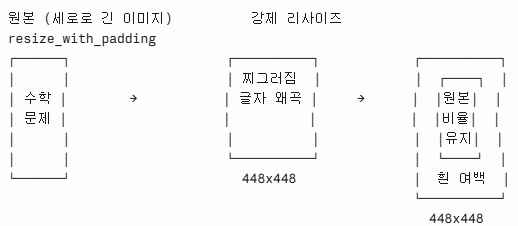
  2. max_new_tokens 128→256 — 텍스트 잘림 방지
  3. describe 재시도 — OCR 실패 시 이미지 설명에서 키워드 추출
  4. 함수 키워드 추가 — f(x), g(x), y= + 집합/경우의수 중복 키워드 정리
- **v2 결과**: (Kaggle 실행 후 기록 예정)
- **변경 상세**: `paligemma_v2_changes.md`
- **코드**: `odapReg_paligemma_kaggle.ipynb` (Kaggle)

### 그 외
- 콴다, 매스프레소 등에서 이 문제를 해결하기 위해 시도했던 발전 과정 조사해보기

### 요약

| 시도 | 모델 / 방법 | 주요 파라미터 | 결과 | 한계점 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | ➔ 다음 시도 동기 &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; |
| :---: | :--- | :--- | :--- | :--- | :--- |
| 1 | ViT (vit-base-patch16-34) | 384px, 3 epoch, lr=2e-5 | **test 97%** | 실제 사진에서 실패 (깨끗한 흰 배경만 학습 ➔ 도메인 갭) | 이미지가 아닌 텍스트로 접근해보자 |
| 2 | GOT-OCR2 | zero-shot OCR | 한글 인식 불가 | 중국어가 섞여 나옴, 한국어 미지원 | 한국어 지원 OCR 필요 |
| 3 | PaddleOCR (한국어 모드) | korean lang | 한글 일부 인식, 수식 깨짐 | "다항식"➔"대한다항식 3x", 수식 x²➔x? | OCR 품질 부족 ➔ VLM으로 전환 |
| 4 | Qwen2-VL-2B | zero-shot, 프롬프트 분류 | 항상 "다항식"만 예측 | 한국 수학 교과 지식 없음 | 파인튜닝이 필요 |
| 5 | Qwen2-VL-2B + LoRA | 약 100개 샘플, LoRA | **10%** (mode collapse) | 학습 데이터 100개로는 부족 + VLM 파인튜닝 난이도 높음 | 텍스트 기반 분류로 성능 확인 |
| 6 | KLUE-RoBERTa (텍스트 분류) | question_text 입력 | **95%+** | JSON의 원본 텍스트 사용 ➔ 사진 입력 불가 | 텍스트면 잘 되니, 이미지➔텍스트 변환이 관건 |
| 7 | ViT + 강한 Augmentation | ColorJitter, Blur, Affine, Perspective 등 | val **57.8%** | augmentation이 너무 강해 학습 방해 | 단계적 학습으로 접근 변경 |
| 8 | ViT 2단계 학습 | Stage1: 3ep 원본 ➔ Stage2: 5ep 약한 aug, lr=5e-6 | *(실행 예정)* | 깨끗한 이미지 정확도 유지하며 실사진 대응력 확보 목표 | - |
| 9 | PaliGemma2-3B (zero-shot OCR+키워드) | 448px, float16, max_token 256 | 전체 **48%**, OCR 성공 시 **80%** | OCR 실패율 39% (한글 인식 한계), 규칙 기반 분류 취약 | end-to-end 학습 필요 |
| 10 | PaliGemma2-3B + QLoRA (예정) | rank ~~816, 9K train,~~ 23 epoch | *(실행 예정)* | 이미지➔단원 직접 학습으로 OCR 의존 탈피 목표 | - |


## Step 11. 회고

시작은 단순했다.<br>
처음 이 프로젝트를 시작할 때의 목표는 단순했다. <br>
아들이 틀린 수학 문제를 휴대폰이나 패드로 사진을 찍으면, 그 문제가 어떤 단원인지 자동으로 분류해주는 모델을 만들자.<br>
LLM을 사용할 수 있는 API를 연결하면 되겠지만, 비용문제도 고민해야하고, 마침 수업의 프로젝트를 자유로 설정해주셔서 직접 나의 모델을 만들어 보자 생각했다.<br>"이미지 분류니까 ViT로 fine-tuning 하면 되겠지"라는 생각으로 가볍게 시작했다.<br>
실제로 시도 1에서 test 정확도 97%가 나왔을 때는 거의 다 끝난 줄 알았다.<br><br>

하지만 실제 사진을 넣어본 순간 현실을 마주했다.<br>
깨끗한 흰 배경의 AI Hub 이미지와, 내가 찍은 채점/풀이흔적 있는 사진은 완전히 다른 세상이었다.<br>
97%라는 숫자가 무의미해지는 순간이었고, 그때부터 진짜 실험이 시작되었다.<br><br>

**모델 선택이 가장 중요한 결정이었다.**<br>
무작정 오답 문제 사진을 단원 분류하는 분류 모델을 만들겠다고 시작했는데,
결국 이 프로젝트에서 가장 중요한 것은 어떤 모델을 써야 하는가였다.<br>
LLM, VLM, ViT, OCR — 이름도 들어보지 못했던 모델들을 직접 실험하면서, 아직 완전히 다 소화하진 못했지만, 짧은 시간 동안에 각각의 강점과 한계를 몸으로 체감할 수 있었다.<br><br>

**ViT:** 이미지 분류에 강하지만, 학습 데이터와 실제 데이터의 갭을 넘지 못한다.<br>
**OCR 모델들 (GOT-OCR2, PaddleOCR):** 영어는 잘 되지만 한국어 수학 문제는 아직 먼 길이다.<br>
**VLM (Qwen2-VL, PaliGemma):** 이미지를 "이해"할 수 있지만, 한국 교과 도메인 지식이 없으면 zero-shot으로는 한계가 있다.<br>
**텍스트 분류 (KLUE-RoBERTa):** 텍스트만 있으면 95%를 넘기는데, 문제는 그 텍스트를 사진에서 꺼내는 것이다.<br><br>
이 과정에서 깨달은 건, **하나의 모델이 모든 걸 해결해주진 않는다**는 것이다.
"어떤 모델을 쓸 것인가"가 아니라 "**어떤 모델을 어떻게 조합할 것인가**"가 진짜 질문이었다.<br><br>

배움의 연속<br>
사실 AI나 딥러닝에 대한 배움이나 이해도가 깊지 않은 상태에서 시작했다.<br>
공부하면서 동시에 실험하고, 실패하면 왜 실패했는지 찾아보고, 다시 시도하는 과정의 반복이었다.<br>
시간도 많이 걸리고 힘들었지만, "오답 문제 자동 분류"라는 대단하진 않으나, 뚜렷한 목표가 있었기에 계속 나아갈 수 있었던 것 같다.<br><br>

**이 과정에서 얻은 것들:**<br>

**HuggingFace 활용법:** 모델 검색, 다운로드, fine-tuning 파이프라인을 직접 다루면서 HuggingFace가 단순한 모델 저장소가 아니라 실험의 핵심 인프라임을 알게 되었다.<br>
**AI Hub 데이터 활용:** 한국어 특화 데이터셋(수학문제(이미지-정보), 038 손글씨)을 발견하고 실제 학습에 활용하는 경험을 쌓았다. 좋은 데이터가 좋은 모델의 시작이라는 걸 실감했다.<br>
**Kaggle 환경 활용:** T4 GPU로 3B 모델을 돌리기 위해 물론 AI들의 도움이 크지만, QLoRA, float16, 메모리 최적화 등을 자연스럽게 익히게 되었다.<br>
**실패에서 배우는 법:** 시도 1의 97%에서 기뻐했다가, 실사진에서 처참하게 실패하고, OCR이 안 되고, VLM이 mode collapse를 일으키는 과정 하나하나가 다 배움이었다.<br><br>
**아직 시도해 볼 것들은 너무나 많다.**<br>
어제 하루동안 깊이있게 모델별로 케이스를 다 다뤄보진 못했다.<br>
기대와 절망이 연속되는 시간이었지만, 성과를 내기 위해 시도해 보는 과정이,  옛날 WEB 프로그래밍 처음 도입되던 시절 맨땅에 헤딩하며 밤새며 코딩하던 시간들이 생각이 많이 났다.<br><br>
현재 PaliGemma 개선과 PaliGemma + QLoRA fine tunnug으로 계속 진행해 볼 것이고, 그것도 잘 되지 않는다면, 콴다 같은 실제 업계에서 어떻게 해결했는지를 좀더 조사해서 적용해 볼 계획이다.<br><br>

최종 목표인 "아들이 찍은 실제 사진에서 80% 이상 분류"는 아직 달성하지 못했지만 이 과정 자체가 가치 있었다고 확신한다.<br>
몰랐던 모델들을 알아가고, 각각의 특성을 직접 실험하며 이해하고,
HuggingFace와 AI Hub를 어떻게 활용해야 하는지 배운 시간이었다.
